<a href="https://colab.research.google.com/github/panhpham2000/Fresh-Retail/blob/Hossam/Copy_of_freshretail_starter_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fresh Retail: Starter Notebook

This notebook accompanies the **Introduction** slide deck (`FreshRetail_Introduction.pptx`). It provides a shared data pipeline for both tracks, then produces the exact outputs previewed in the showcase slides.

**Run sections 1–4 first** (shared setup), then run the section for your track:

| Section | Track | What you produce |
|---------|-------|-----------------|
| 5. Operations | Ops | Temporal profiles, heatmaps, KPIs, hourly patterns |
| 6. Data Science | DS | WAPE baselines, forecast overlays, demand recovery, error analysis |

Both tracks use the same dataset, same helper functions, and same time split.

- **Operations Track**: O1 (Diagnosis) or O2 (Decision)
- **Data Science Track**: D1 (Direct benchmark) or D2 (Recovery first)

**Dataset**: [Dingdong-Inc/FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K)

---
## 1. Setup and Data Download

In [ ]:
# Run this cell on Google Colab (already installed locally)
!pip install -q pandas pyarrow matplotlib seaborn datasets

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Setup complete.")

Setup complete.


In [ ]:
from datasets import load_dataset

print("Downloading FreshRetailNet-50K from Hugging Face...")
ds = load_dataset("Dingdong-Inc/FreshRetailNet-50K")
print(ds)

# Convert to pandas
train_raw = ds["train"].to_pandas()
eval_raw = ds["eval"].to_pandas()

print(f"\nTrain: {train_raw.shape}, Eval: {eval_raw.shape}")
print(f"Columns: {list(train_raw.columns)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.87k [00:00<?, ?B/s]

data/train.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

data/eval.parquet:   0%|          | 0.00/8.44M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4500000 [00:00<?, ? examples/s]

Generating eval split:   0%|          | 0/350000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level'],
        num_rows: 4500000
    })
    eval: Dataset({
        features: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level'],
        num_rows: 350000
    })
})

Train: (4500000, 19), Eval: (350000, 19)
Columns: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'sto

---
## 2. Data Preparation

In [ ]:
def prepare_panel(df: pd.DataFrame) -> pd.DataFrame:
    """Prepare the raw HF dataset into a clean analysis panel."""
    df = df.copy()

    # Parse date
    df["dt"] = pd.to_datetime(df["dt"])
    df = df.sort_values(["store_id", "product_id", "dt"]).reset_index(drop=True)

    # Create series_id (unique store x product combination)
    series_keys = df[["store_id", "product_id"]].drop_duplicates().reset_index(drop=True)
    series_keys["series_id"] = range(1, len(series_keys) + 1)
    df = df.merge(series_keys, on=["store_id", "product_id"], how="left")

    # Create day index (days since start)
    min_date = df["dt"].min()
    df["day_idx"] = (df["dt"] - min_date).dt.days + 1

    n_series = df["series_id"].nunique()
    n_days = df["day_idx"].nunique()
    print(f"Prepared {len(df):,} rows \u2014 {n_series:,} series x {n_days} days")
    print(f"Date range: {df['dt'].min().date()} to {df['dt'].max().date()}")
    return df


history = prepare_panel(train_raw)
history.head()

Prepared 4,500,000 rows — 50,000 series x 90 days
Date range: 2024-03-28 to 2024-06-25


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,...,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,series_id,day_idx
0,0,0,2,29,78,82,4,2024-03-28,0.5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, ...",...,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, ...",0.882,0,1,1.6999,15.48,73.54,1.97,1,1
1,0,0,2,29,78,82,4,2024-03-29,1.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.882,0,1,3.0190,15.08,76.56,1.71,1,2
2,0,0,2,29,78,82,4,2024-03-30,5.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.882,1,1,2.0942,15.91,76.47,1.73,1,3
3,0,0,2,29,78,82,4,2024-03-31,4.2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.879,1,1,1.5618,16.13,77.40,1.76,1,4
4,0,0,2,29,78,82,4,2024-04-01,0.7,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.882,0,1,3.5386,15.37,78.26,1.25,1,5


---
## 3. Shared Functions: flag_censoring, make_features, time_split

In [ ]:
def flag_censoring(df: pd.DataFrame) -> pd.DataFrame:
    """Add censoring flags based on stockout hours."""
    df = df.copy()
    df["is_censored"] = (df["stock_hour6_22_cnt"] > 0).astype(int)
    df["censoring_severity"] = df["stock_hour6_22_cnt"] / 16
    print(f"Censored rows: {df['is_censored'].sum():,} / {len(df):,} ({df['is_censored'].mean():.1%})")
    return df


def make_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add lag and rolling features for EDA and forecasting."""
    df = df.sort_values(["series_id", "day_idx"]).copy()
    grp = df.groupby("series_id")["sale_amount"]
    df["sales_lag1"] = grp.shift(1)
    df["sales_lag7"] = grp.shift(7)
    df["sales_roll7"] = grp.transform(lambda x: x.rolling(7, min_periods=1).mean())
    df["sales_roll28"] = grp.transform(lambda x: x.rolling(28, min_periods=1).mean())
    df["psd"] = grp.transform("mean")  # per-series daily mean
    return df


def time_split(df: pd.DataFrame, horizon: int = 7) -> tuple:
    """Split into train and validation by time. Validation = last `horizon` days."""
    min_day = df["day_idx"].min()
    max_day = df["day_idx"].max()
    val_start = max_day - horizon + 1
    train = df[df["day_idx"] < val_start].copy()
    val = df[df["day_idx"] >= val_start].copy()
    print(f"Train: day {min_day}..{val_start - 1} ({len(train):,} rows), Val: day {val_start}..{max_day} ({len(val):,} rows)")
    return train, val

In [ ]:
# Apply shared pipeline
history = flag_censoring(history)
history = make_features(history)

train, val = time_split(history, horizon=7)
print(f"\nValidation window: day {val['day_idx'].min()} to {val['day_idx'].max()}")

Censored rows: 1,992,006 / 4,500,000 (44.3%)
Train: day 1..83 (4,150,000 rows), Val: day 84..90 (350,000 rows)

Validation window: day 84 to 90


---
## 4. Data at a Glance

In [ ]:
# Show a real series with stockouts
series_stockouts = history.groupby("series_id")["is_censored"].mean()
example_sid = series_stockouts[(series_stockouts > 0.3) & (series_stockouts < 0.7)].index[0]

s_example = history[history["series_id"] == example_sid][
    ["dt", "day_idx", "sale_amount", "stock_hour6_22_cnt", "is_censored", "discount", "holiday_flag", "avg_temperature"]
].head(14)
print(f"Series {example_sid} \u2014 first 14 days (a product with frequent stockouts):")
display(s_example)

In [ ]:
# Dataset dimensions
summary = pd.Series({
    "Total rows": f"{len(history):,}",
    "Series (store x product)": f"{history['series_id'].nunique():,}",
    "Days per series": str(history["day_idx"].nunique()),
    "Products (product_id)": str(history["product_id"].nunique()),
    "Stores (store_id)": str(history["store_id"].nunique()),
    "Cities (city_id)": str(history["city_id"].nunique()),
    "Management groups": str(history["management_group_id"].nunique()),
    "Mean daily sales": f"{history['sale_amount'].mean():.3f}",
    "Censored rows": f"{history['is_censored'].sum():,} ({history['is_censored'].mean():.1%})",
    "Low-sale series (psd<1)": f"{(history.groupby('series_id')['psd'].first() < 1).sum():,}",
    "High-sale series (psd>=1)": f"{(history.groupby('series_id')['psd'].first() >= 1).sum():,}",
})
display(summary.to_frame("Value"))

In [ ]:
# Sales distribution and per-series daily mean
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clipped = history["sale_amount"].clip(upper=history["sale_amount"].quantile(0.99))
axes[0].hist(clipped, bins=50, color="#065A82", edgecolor="white")
axes[0].set_title("Distribution of daily sales (clipped at 99th pctl)")
axes[0].set_xlabel("sale_amount")
axes[0].set_ylabel("Count")

psd_vals = history.groupby("series_id")["psd"].first()
axes[1].hist(psd_vals, bins=50, color="#1C7293", edgecolor="white")
axes[1].axvline(1.0, color="#E74C3C", linestyle="--", linewidth=2, label="psd=1 cutoff")
axes[1].set_title("Per-series daily mean (psd) distribution")
axes[1].set_xlabel("psd")
axes[1].set_ylabel("Number of series")
axes[1].legend()

plt.tight_layout()
plt.show()



## 6. Data Science Track

> **You may skip this section if you are focusing on the Operations track.**

This section produces the following outputs — each corresponds to a slide in the deck:

| Output | What it shows | Slide |
|--------|--------------|-------|
| WAPE results table (D1) | Baseline comparison: global mean vs seasonal naive vs rolling 28d | Slide 18 |
| Forecast overlay chart | Predicted vs actual for one series across the validation window | Slide 18 |
| Recovery comparison table (D2) | WAPE on raw vs corrected target — does imputation help? | Slide 19 |
| WAPE by management group | Which product groups are hardest to forecast? | Slide 20 |
| Residual histogram + error scatter | Where the model fails and why | Slide 20 |

**A strong data science project** starts from these baselines and improves on them with better features, better imputation, or a more sophisticated model — always measured by WAPE on the same time split.

### 6a. WAPE Evaluation Function

In [ ]:
def compute_wape(actual: np.ndarray, predicted: np.ndarray) -> float:
    """Weighted Absolute Percentage Error."""
    denom = np.sum(np.abs(actual))
    if denom == 0:
        return np.nan
    return np.sum(np.abs(actual - predicted)) / denom


def evaluate_forecast(val_df: pd.DataFrame, pred_col: str = "prediction") -> dict:
    """Compute WAPE overall, low-sale, high-sale, and harmonic mean.
    Only evaluates rows where stock_hour6_22_cnt == 0 (uncensored in validation)."""
    scored = val_df[val_df["stock_hour6_22_cnt"] == 0].copy()
    if len(scored) == 0:
        return {"wape_overall": np.nan}

    y = scored["sale_amount"].values
    yhat = scored[pred_col].values

    wape_all = compute_wape(y, yhat)

    low = scored[scored["psd"] < 1]
    high = scored[scored["psd"] >= 1]

    wape_low = compute_wape(low["sale_amount"].values, low[pred_col].values) if len(low) > 0 else np.nan
    wape_high = compute_wape(high["sale_amount"].values, high[pred_col].values) if len(high) > 0 else np.nan

    if np.isnan(wape_low) or np.isnan(wape_high) or wape_all == 0 or wape_low == 0 or wape_high == 0:
        hm = np.nan
    else:
        hm = 3 / (1/wape_all + 1/wape_low + 1/wape_high)

    return {
        "wape_overall": round(wape_all, 4) if not np.isnan(wape_all) else np.nan,
        "wape_low_sale": round(wape_low, 4) if not np.isnan(wape_low) else np.nan,
        "wape_high_sale": round(wape_high, 4) if not np.isnan(wape_high) else np.nan,
        "harmonic_mean": round(hm, 4) if not np.isnan(hm) else np.nan,
        "scored_rows": len(scored),
    }

print("Evaluation function ready.")

Evaluation function ready.


### 6b. D1 \u2014 Direct Benchmark: Naive Baselines on Raw Sales

In [ ]:
# --- Baseline 1: Global mean ---
series_mean = train.groupby("series_id")["sale_amount"].mean().rename("pred_global_mean")
val = val.drop(columns=["pred_global_mean", "pred_seasonal_naive", "pred_roll28", "forecast_day"], errors="ignore")
val = val.merge(series_mean, on="series_id", how="left")

# --- Baseline 2: Seasonal naive (last-week repeat) ---
val_start = val["day_idx"].min()
last_week = history[history["day_idx"].between(val_start - 7, val_start - 1)][["series_id", "day_idx", "sale_amount"]].copy()
last_week["forecast_day"] = last_week["day_idx"] + 7
last_week = last_week.rename(columns={"sale_amount": "pred_seasonal_naive"})

val = val.merge(last_week[["series_id", "forecast_day", "pred_seasonal_naive"]],
                left_on=["series_id", "day_idx"], right_on=["series_id", "forecast_day"], how="left")
val = val.drop(columns=["forecast_day"], errors="ignore")
val["pred_seasonal_naive"] = val["pred_seasonal_naive"].fillna(val["pred_global_mean"])

# --- Baseline 3: Rolling 28-day mean ---
roll28 = train.groupby("series_id")["sale_amount"].apply(
    lambda x: x.tail(28).mean(), include_groups=False
).rename("pred_roll28")
val = val.merge(roll28, on="series_id", how="left")

# Evaluate all three
results = {}
for method, col in [("Global mean", "pred_global_mean"), ("Seasonal naive", "pred_seasonal_naive"), ("Rolling 28d", "pred_roll28")]:
    val["prediction"] = val[col].clip(lower=0)
    results[method] = evaluate_forecast(val)

results_df = pd.DataFrame(results).T
print("=== D1 Benchmark Results ===")
display(results_df)

In [ ]:
# --- Visualize: forecast overlay for one series ---
example_sid3 = history.groupby("series_id")["psd"].first().sort_values(ascending=False).index[5]
ex = history[history["series_id"] == example_sid3].copy()
ex_val = val[val["series_id"] == example_sid3].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ex["day_idx"], ex["sale_amount"], color="#065A82", linewidth=1.5, label="Actual (train)")
ax.plot(ex_val["day_idx"], ex_val["sale_amount"], color="#065A82", linewidth=2, linestyle="-", label="Actual (val)")
ax.plot(ex_val["day_idx"], ex_val["pred_global_mean"], color="#E67E22", linewidth=1.5, linestyle="--", label="Global mean")
ax.plot(ex_val["day_idx"], ex_val["pred_seasonal_naive"], color="#8E44AD", linewidth=1.5, linestyle="--", label="Seasonal naive")
ax.plot(ex_val["day_idx"], ex_val["pred_roll28"], color="#27AE60", linewidth=1.5, linestyle="--", label="Rolling 28d")

ax.axvline(ex_val["day_idx"].min() - 0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_title(f"Series {example_sid3}: Forecast overlay (validation window)")
ax.set_xlabel("day_idx")
ax.set_ylabel("sale_amount")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 6c. D2 \u2014 Recovery First: Impute Censored Hours, Then Forecast

In [ ]:
# Expand hourly data from the list columns
# Note: this creates large arrays (~550MB). Colab free tier (12GB RAM) handles this fine.
print("Expanding hourly data...")

hourly_sales = np.stack(history["hours_sale"].values)          # (N, 24)
hourly_stock_ds = np.stack(history["hours_stock_status"].values)  # (N, 24)

# Focus on operating window h06..h21 (indices 6..21, 16 hours)
op_sales = hourly_sales[:, 6:22].astype(np.float32)
op_stock = hourly_stock_ds[:, 6:22].astype(np.float32)

# Mark censored hours
op_sales_masked = np.where(op_stock == 1, np.nan, op_sales)

total_cells = op_sales_masked.size
missing_cells = np.isnan(op_sales_masked).sum()
print(f"Operating window: {op_sales_masked.shape[1]} hours (h06-h21)")
print(f"Missing hourly cells: {missing_cells:,} / {total_cells:,} ({missing_cells/total_cells:.1%})")

Expanding hourly data...
Operating window: 16 hours (h06-h21)
Missing hourly cells: 14,311,536 / 72,000,000 (19.9%)


In [ ]:
# --- Simple recovery: random pool sampling ---
visible_sum = np.nansum(np.where(op_stock == 0, op_sales, 0), axis=1)

imputed = op_sales_masked.copy()
imputed_count = 0
for h in range(16):
    col = imputed[:, h]
    mask = np.isnan(col)
    n_miss = mask.sum()
    if n_miss > 0:
        pool = col[~mask]
        imputed[mask, h] = np.maximum(0, rng.choice(pool, size=n_miss, replace=True))
        imputed_count += n_miss

# Rebuild corrected daily target
recovered_sum = np.nansum(imputed, axis=1)
outside_slice = np.maximum(history["sale_amount"].values.astype(np.float32) - visible_sum, 0)
recovered_daily = outside_slice + recovered_sum

history["recovered_daily_sales"] = recovered_daily

print(f"Imputed {imputed_count:,} hourly cells")
print(f"Mean raw sale_amount: {history['sale_amount'].mean():.4f}")
print(f"Mean recovered sales: {history['recovered_daily_sales'].mean():.4f}")

Imputed 14,311,536 hourly cells
Mean raw sale_amount: 0.9986
Mean recovered sales: 1.1973


In [ ]:
# Re-split with recovered target
train_r, val_r = time_split(history, horizon=7)

# Seasonal naive on recovered target
val_start_r = val_r["day_idx"].min()
last_week_r = history[history["day_idx"].between(val_start_r - 7, val_start_r - 1)][
    ["series_id", "day_idx", "recovered_daily_sales"]
].copy()
last_week_r["forecast_day"] = last_week_r["day_idx"] + 7
last_week_r = last_week_r.rename(columns={"recovered_daily_sales": "pred_recovered_naive"})

val_r = val_r.merge(
    last_week_r[["series_id", "forecast_day", "pred_recovered_naive"]],
    left_on=["series_id", "day_idx"], right_on=["series_id", "forecast_day"], how="left",
)
val_r = val_r.drop(columns=["forecast_day"], errors="ignore")
fallback = train_r.groupby("series_id")["recovered_daily_sales"].mean()
val_r["pred_recovered_naive"] = val_r["pred_recovered_naive"].fillna(val_r["series_id"].map(fallback))

# Also add seasonal naive on raw for fair comparison
val_r = val_r.merge(
    val[["series_id", "day_idx", "pred_seasonal_naive"]].drop_duplicates(),
    on=["series_id", "day_idx"], how="left",
)

# Evaluate both
d2_results = {}
for method, col in [("Seasonal naive (raw)", "pred_seasonal_naive"), ("Seasonal naive (recovered)", "pred_recovered_naive")]:
    val_r["prediction"] = val_r[col].clip(lower=0)
    d2_results[method] = evaluate_forecast(val_r)

d2_df = pd.DataFrame(d2_results).T
print("=== D2 Recovery Comparison ===")
display(d2_df)

### 6d. Error Analysis

In [ ]:
# WAPE by management group
scored = val[val["stock_hour6_22_cnt"] == 0].copy()
scored["prediction"] = scored["pred_seasonal_naive"].clip(lower=0)
scored["abs_error"] = np.abs(scored["sale_amount"] - scored["prediction"])

group_wape = scored.groupby("management_group_id").apply(
    lambda g: compute_wape(g["sale_amount"].values, g["prediction"].values),
    include_groups=False
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
group_wape.plot(kind="barh", color="#1C7293", edgecolor="white", ax=ax)
ax.set_title("WAPE by management group (seasonal naive baseline)")
ax.set_xlabel("WAPE")
ax.set_ylabel("Management Group ID")
plt.tight_layout()
plt.show()

In [ ]:
# Residual distribution and error vs stockout frequency
scored["residual"] = scored["sale_amount"] - scored["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(scored["residual"].clip(-5, 5), bins=60, color="#065A82", edgecolor="white")
axes[0].axvline(0, color="#E74C3C", linestyle="--", linewidth=2)
axes[0].set_title("Residual distribution (seasonal naive)")
axes[0].set_xlabel("Actual - Predicted")
axes[0].set_ylabel("Count")

series_error = scored.groupby("series_id").agg(
    mean_abs_error=("abs_error", "mean"),
).reset_index()
series_error = series_error.merge(
    history.groupby("series_id")["is_censored"].mean().rename("stockout_freq"),
    on="series_id"
)
axes[1].scatter(series_error["stockout_freq"], series_error["mean_abs_error"], alpha=0.1, s=5, color="#065A82")
axes[1].set_title("Mean absolute error vs stockout frequency")
axes[1].set_xlabel("Stockout frequency")
axes[1].set_ylabel("Mean absolute error")

plt.tight_layout()
plt.show()

### VISUALISATION 7: Censoring Rate vs Forecast Error (LightGBM D1)

Core evidence for D2: series with more censoring have larger forecast errors. This is the academic motivation for demand recovery.

In [ ]:
# Censoring Rate vs Forecast Error (LightGBM D1)
# =============================================================================
# This visualization uses the LightGBM results from D1 (all features).

series_stats_d1 = (
    history.groupby("series_id")
    .agg(
        censoring_rate=("is_censored", "mean"),
        psd=("psd", "first"),
    )
    .reset_index()
)

# 'scored_lgbm_d1' was previously created for D1 LightGBM error analysis.
# It contains 'prediction' based on 'val_Lgbm' and filtered for uncensored rows.
scored_only_d1 = val_Lgbm[val_Lgbm["stock_hour6_22_cnt"] == 0].copy()

series_errors_d1 = (
    scored_only_d1
    .groupby("series_id")
    .apply(lambda g: compute_wape(g["sale_amount"].values, g["prediction"].values))
    .reset_index()
)
series_errors_d1.columns = ["series_id", "series_wape"]

series_plot_d1 = series_stats_d1.merge(series_errors_d1, on="series_id")
# Keep only series with reasonable WAPE (exclude outliers for readability)
series_plot_d1 = series_plot_d1[series_plot_d1["series_wape"] < 2]

sample_plot_d1 = series_plot_d1.sample(min(8000, len(series_plot_d1)), random_state=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(
    sample_plot_d1["censoring_rate"],
    sample_plot_d1["series_wape"],
    c=sample_plot_d1["psd"],
    cmap="viridis",
    alpha=0.3, s=8,
)
plt.colorbar(scatter, ax=ax, label="Per-Series Daily Mean (psd)")

# Trend line
z_d1 = np.polyfit(sample_plot_d1["censoring_rate"], sample_plot_d1["series_wape"], 1)
p_d1 = np.poly1d(z_d1)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, p_d1(x_line), color="red", linewidth=2,
        label=f"Trend (slope={z_d1[0]:.3f})")

ax.set_title("Per-Series WAPE vs Censoring Rate (LightGBM D1)\nHigher censoring \u2192 worse forecast \u2014 direct motivation for D2")
ax.set_xlabel("Censoring Rate (fraction of days with stockout)")
ax.set_ylabel("Per-Series WAPE (LightGBM D1)")
ax.legend()
plt.tight_layout()
plt.show()

# Correlation statistic
corr_d1 = series_plot_d1[["censoring_rate", "series_wape"]].corr().iloc[0, 1]
print(f"Pearson correlation (censoring rate vs WAPE, D1): {corr_d1:.3f}")

In [ ]:
print("Implementing Per-Series Hourly Mean recovery (leakage-free)...")

# --- Start: Necessary definitions moved from fyqpkO6BPLFc to ensure scope ---
# Expand hourly data from the list columns
# Note: this creates large arrays (~550MB). Colab free tier (12GB RAM) handles this fine.
print("Expanding hourly data...")

hourly_sales = np.stack(history["hours_sale"].values)          # (N, 24)
hourly_stock_ds = np.stack(history["hours_stock_status"].values)  # (N, 24)

# Focus on operating window h06..h21 (indices 6..21, 16 hours)
op_sales = hourly_sales[:, 6:22].astype(np.float32)
op_stock = hourly_stock_ds[:, 6:22].astype(np.float32)

# Mask censored hours
op_sales_masked = np.where(op_stock == 1, np.nan, op_sales)

total_cells = op_sales_masked.size
missing_cells = np.isnan(op_sales_masked).sum()
print(f"Operating window: {op_sales_masked.shape[1]} hours (h06-h21)")
print(f"Missing hourly cells: {missing_cells:,} / {total_cells:,} ({missing_cells/total_cells:.1%})")
# --- End: Necessary definitions moved ---


# Determine the validation start day from the original time_split for training data
# This ensures the means are calculated only from the training period
val_start_pshm_calc = history['day_idx'].max() - 7 + 1 # horizon is 7

# Filter history to create a training-only view for mean calculation
train_history_for_pshm_calc = history[history["day_idx"] < val_start_pshm_calc].copy()

# Calculate per-series hourly means FOR TRAINING DATA ONLY
per_series_hourly_mean_data = {}

# Iterate through unique series_id present in the training data
train_series_ids = train_history_for_pshm_calc['series_id'].unique()

for series_id in train_series_ids:
    # Get the original history indices that correspond to this series_id AND are in the training set
    original_history_indices_for_series_in_train = train_history_for_pshm_calc[train_history_for_pshm_calc['series_id'] == series_id].index

    # Extract the operating window sales and stock status for this series
    # from the FULL op_sales/op_stock arrays, but only for the training period rows.
    series_op_sales_train = op_sales[original_history_indices_for_series_in_train, :]
    series_op_stock_train = op_stock[original_history_indices_for_series_in_train, :]

    # Mask sales for stockouts within this series' training data
    series_op_sales_masked_train = np.where(series_op_stock_train == 1, np.nan, series_op_sales_train)

    # Initialize hourly_means with NaN for all hours
    hourly_means = np.full(series_op_sales_masked_train.shape[1], np.nan)

    # Calculate the mean for each hour for this specific series, ignoring NaNs
    # This mean is based ONLY on training data for this series, avoiding leakage.
    # Explicitly check for all-NaN slices to prevent RuntimeWarning
    for hour_idx in range(series_op_sales_masked_train.shape[1]):
        hour_sales_data = series_op_sales_masked_train[:, hour_idx]
        if not np.all(np.isnan(hour_sales_data)):
            hourly_means[hour_idx] = np.nanmean(hour_sales_data)

    per_series_hourly_mean_data[series_id] = hourly_means

# Impute using per-series hourly mean (apply to the full masked data using means from training)
imputed_pshm = op_sales_masked.copy() # Start with the full masked data

imputed_count_pshm = 0

for i in range(len(history)): # Iterate over each series-day observation in the full history
    current_series_id = history['series_id'].iloc[i]

    # Get the pre-calculated hourly means for this series (derived from training data)
    series_hourly_means = per_series_hourly_mean_data.get(current_series_id)

    if series_hourly_means is not None: # Means exist for this series from training data
        for h in range(16): # Iterate over each hour in the operating window
            if np.isnan(imputed_pshm[i, h]):
                mean_val = series_hourly_means[h]
                if not np.isnan(mean_val): # Only impute if a mean exists for this series-hour
                    imputed_pshm[i, h] = np.maximum(0, mean_val)
                    imputed_count_pshm += 1
                else:
                    # Fallback if specific series-hour mean is NaN (e.g., this series always censored for this hour in training)
                    imputed_pshm[i, h] = 0
    else:
        # If a series_id is in history but not in train_series_ids (e.g., it only appears in validation),
        # its hourly_means won't be in per_series_hourly_mean_data. Impute with 0 in this case.
        for h in range(16):
            if np.isnan(imputed_pshm[i, h]):
                imputed_pshm[i, h] = 0


# Rebuild corrected daily target (using the imputed_pshm which now covers the full history)
# visible_sum is from the original op_sales (non-censored hours)
visible_sum_pshm = np.nansum(np.where(op_stock == 0, op_sales, 0), axis=1)
recovered_sum_pshm = np.sum(imputed_pshm, axis=1) # Sum of the (now) fully imputed hourly sales

# outside_slice is sales outside operating hours, adjusted to be non-negative
outside_slice_pshm = np.maximum(history["sale_amount"].values.astype(np.float32) - visible_sum_pshm, 0)
recovered_daily_pshm = outside_slice_pshm + recovered_sum_pshm

history["recovered_daily_sales_pshm"] = recovered_daily_pshm

print(f"Imputed {imputed_count_pshm:,} hourly cells using per-series hourly mean (training data only).")
print(f"Mean raw sale_amount: {history['sale_amount'].mean():.4f}")
print(f"Mean recovered sales (per-series hourly mean): {history['recovered_daily_sales_pshm'].mean():.4f}")

# Re-split with recovered target (this will now use the newly updated history)
train_r_pshm, val_r_pshm = time_split(history, horizon=7)

# LGBMRegressor on per-series hourly mean recovered sales
from lightgbm import LGBMRegressor

# Drop missing values from the train_r_pshm and val_r_pshm dataframes
# (these were already created from history with 'recovered_daily_sales_pshm')
train_Lgbm_pshm = train_r_pshm.dropna()
val_Lgbm_pshm = val_r_pshm.dropna()

features_lgbm = [
    "sales_lag1",
    "sales_lag7",
    "sales_roll7",
    "sales_roll28",
    "avg_temperature",
    'management_group_id',
    'city_id',
    'product_id',
    'holiday_flag',
    'is_censored',
    'discount'
]

target_lgbm_pshm = "recovered_daily_sales_pshm"

model_pshm = LGBMRegressor(random_state=1)
model_pshm.fit(train_Lgbm_pshm[features_lgbm], train_Lgbm_pshm[target_lgbm_pshm])

val_Lgbm_pshm["prediction"] = model_pshm.predict(val_Lgbm_pshm[features_lgbm])
val_Lgbm_pshm["prediction"] = val_Lgbm_pshm["prediction"].clip(lower=0)

print("=== LGBMRegressor on Per-Series Hourly Mean Recovered Data (Leakage-Free) ===")
# When evaluating, 'sale_amount' should be the actual target, which is recovered_daily_sales_pshm
val_Lgbm_pshm_eval = val_Lgbm_pshm.copy()
val_Lgbm_pshm_eval["sale_amount"] = val_Lgbm_pshm_eval[target_lgbm_pshm]

pshm_lgbm_results = evaluate_forecast(val_Lgbm_pshm_eval)
print(pshm_lgbm_results)

# If all_recovery_results is not in scope, this would need re-initialization or a new comparison table
# For now, let's just display it and assume it can be merged later.


---
---
## 7. Next Steps

### Operations Track

**O1 \u2014 Diagnosis First**
- Extend the heatmaps to find which store x category combinations are most fragile
- Test whether promotions (`discount < 1`) increase late-day stockouts
- Run panel regressions with fixed effects to isolate drivers

**O2 \u2014 Decision First**
- Build a simple corrected demand estimate (impute censored hours from `hours_sale`)
- Compute newsvendor order quantities under raw vs. corrected demand
- Visualize the service vs. waste trade-off curve

### Data Science Track

**D1 \u2014 Direct Benchmark**
- Try exponential smoothing or a simple LightGBM with lag features
- Analyze errors by day-of-week to detect weekly patterns
- Compare WAPE across cities to find geographic patterns

**D2 \u2014 Recovery First**
- Try per-series mean imputation instead of global pool sampling
- Compare multiple recovery strategies on the same baseline
- Focus error analysis on high-stockout series where recovery matters most

### Cross-Track Synergies
- Operations insights (which products are most fragile) can inform DS feature engineering
- DS demand recovery estimates can feed back into operations policy evaluation
- Both tracks benefit from understanding the hourly censoring structure

### 7a. D1 - Direct Forecasting

#### D1 — LightGBM with lag features

In [ ]:
from lightgbm import LGBMRegressor

# drop missing value
train_Lgbm = train.dropna()
val_Lgbm = val.dropna()

features_lag = [
    "sales_lag1",
    "sales_lag7",
    "sales_roll7",
    "sales_roll28"
]

target = "sale_amount"

model = LGBMRegressor(random_state=1)
model.fit(train_Lgbm[features_lag], train_Lgbm[target])

val_Lgbm["prediction"] = model.predict(val_Lgbm[features_lag])
val_Lgbm["prediction"] = val_Lgbm["prediction"].clip(lower=0)

lag_features_results = evaluate_forecast(val_Lgbm)
print(lag_features_results)

**MODEL IMPROVEMENT**

Adding features beyond just lag features is crucial for a more robust and accurate forecasting model.

- Capture External Influences: Lag features only reflect past sales. Other features like `avg_temperature`, `holiday_flag`, and discount capture external factors that directly impact sales but aren't inherent in past sales patterns.
- Contextual Understanding: Features such as `management_group_id`, `city_id`, and `product_id` provide crucial contextual information, allowing the model to learn unique sales behaviors for different entities.
- Address Special Conditions: `is_censored` helps the model understand when low sales were due to stockouts, distinguishing true low demand from supply issues.
Improved Accuracy and
- Generalization: By incorporating these diverse features, the model gains a more complete picture of sales drivers, leading to better predictions and a stronger ability to generalize to new data, leveraging LightGBM's strength in handling various feature types.

In [ ]:
# add other features

features = [
    "sales_lag1",
    "sales_lag7",
    "sales_roll7",
    "sales_roll28",
    "avg_temperature",
    'management_group_id',
    'city_id',
    'product_id',
    'holiday_flag',
    'is_censored',
    'discount'
]

model = LGBMRegressor(random_state=1)
model.fit(train_Lgbm[features], train_Lgbm[target])

val_Lgbm["prediction"] = model.predict(val_Lgbm[features])
val_Lgbm["prediction"] = val_Lgbm["prediction"].clip(lower=0)

all_features_results = evaluate_forecast(val_Lgbm)
print(all_features_results)

In [ ]:

# Create a DataFrame to compare the results
comparison_df = pd.DataFrame({
    'Before (Lag Features Only)': lag_features_results,
    'After (All Features)': all_features_results
}).T # Transpose to have models as rows and metrics as columns

display(comparison_df)

,wape_overall,wape_low_sale,wape_high_sale,harmonic_mean,scored_rows
Before (Lag Features Only),0.2754,0.3345,0.2297,0.2734,198987.0
After (All Features),0.2561,0.3142,0.2111,0.2537,198987.0


**CONCLUSION:**

After incorporating additional features beyond just lag-features into the LightGBM model, we observed a clear improvement in forecasting performance:

The overall WAPE (wape_overall) decreased from 0.2754 to 0.2561.
Similarly, WAPE for low-sale items (wape_low_sale) dropped from 0.3345 to 0.3142.
And WAPE for high-sale items (wape_high_sale) also improved from 0.2297 to 0.2111.
The Harmonic Mean metric also improved from 0.2734 to 0.2537.
This demonstrates that adding features related to environmental factors, context, and special conditions helped the model better understand the drivers of sales, leading to more accurate forecasts. This is a significant improvement!

####D1 — Exponential Smoothing Benchmark

Test with sample of 5000

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler # for normalization


# --- DLinear Model Definition (from previous successful implementation) ---
class MovingAverage(nn.Module):
    def __init__(self, kernel_size, stride):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1)) # permute to (batch, features, sequence_length)
        x = x.permute(0, 2, 1) # permute back
        return x

class DLinear(nn.Module):
    def __init__(self, input_len, pred_len, kernel_size=25): # Changed seq_len to input_len
        super().__init__()
        self.input_len = input_len # Changed seq_len to input_len
        self.pred_len = pred_len
        self.kernel_size = kernel_size

        self.moving_avg = MovingAverage(kernel_size, stride=1)
        self.linear_seasonal = nn.Linear(input_len, pred_len) # Changed seq_len to input_len
        self.linear_trend = nn.Linear(input_len, pred_len) # Changed seq_len to input_len

        # Initialize weights (often set to identity or similar for DLinear)
        nn.init.constant_(self.linear_seasonal.weight, 1.0 / input_len) # Changed seq_len to input_len
        nn.init.constant_(self.linear_trend.weight, 1.0 / input_len) # Changed seq_len to input_len
        nn.init.constant_(self.linear_seasonal.bias, 0.0)
        nn.init.constant_(self.linear_trend.bias, 0.0)

    def forward(self, x): # x: [Batch, Input length, Channel]
        # Decompose the input
        trend = self.moving_avg(x)
        seasonal = x - trend

        # Forecast
        seasonal_output = self.linear_seasonal(seasonal.permute(0, 2, 1)).permute(0, 2, 1)
        trend_output = self.linear_trend(trend.permute(0, 2, 1)).permute(0, 2, 1)

        return seasonal_output + trend_output

# --- Parameters ---
# These are assumed to be globally defined from previous cells or will be defined here if not.
# For consistency, using the names and values established in the conversation.
input_len = 14 # Lookback window (encoder length)
pred_len = 7   # Forecast horizon (decoder length)
epochs = 5     # Number of training epochs per series
learning_rate = 0.001 # Can be tuned after LR finder
batch_size = 128 # Defined for LR finder, used here too.




all_forecasts_dlinear = []

# --- Sample 5000 series for training ---
print("--- DLinear Training on 5000 Sample Series ---")
sample_size = 5000

# Ensure series_id columns are integer type
history["series_id"] = history["series_id"].astype(int)
train["series_id"] = train["series_id"].astype(int)
val["series_id"] = val["series_id"].astype(int)

print(f"history['series_id'] dtype: {history['series_id'].dtype}, head: {history['series_id'].head().tolist()}")
print(f"train['series_id'] dtype: {train['series_id'].dtype}, head: {train['series_id'].head().tolist()}")
print(f"val['series_id'] dtype: {val['series_id'].dtype}, head: {val['series_id'].head().tolist()}")

all_series_ids_for_dlinear = history["series_id"].drop_duplicates().sample(sample_size, random_state=RANDOM_SEED)
print(f"all_series_ids_for_dlinear dtype: {all_series_ids_for_dlinear.dtype}, head: {all_series_ids_for_dlinear.head().tolist()}")

# Filter train and val DataFrames for the sampled series
train_dlinear_full_sample = train[train["series_id"].isin(all_series_ids_for_dlinear)].copy()
val_dlinear_full_sample = val[val["series_id"].isin(all_series_ids_for_dlinear)].copy()

print(f"Length of train_dlinear_full_sample after filtering: {len(train_dlinear_full_sample)}")
print(f"Length of val_dlinear_full_sample after filtering: {len(val_dlinear_full_sample)}")

# Sort for time series processing
train_dlinear_full_sample = train_dlinear_full_sample.sort_values(["series_id", "day_idx"])
val_dlinear_full_sample = val_dlinear_full_sample.sort_values(["series_id", "day_idx"])

print(f"Training DLinear on {len(all_series_ids_for_dlinear)} series...")

series_processed_count = 0
for series_id in all_series_ids_for_dlinear:
    train_series_df = train_dlinear_full_sample[train_dlinear_full_sample["series_id"] == series_id].copy()
    val_series_df = val_dlinear_full_sample[val_dlinear_full_sample["series_id"] == series_id].copy()

    # Skip if not enough data for training sequences or no validation data
    if len(train_series_df) < input_len + pred_len or len(val_series_df) == 0:
        continue

    # Scale data for this series (MinMaxScaler)
    scaler = MinMaxScaler()
    train_sales_scaled = scaler.fit_transform(train_series_df["sale_amount"].values.reshape(-1, 1))

    # Prepare training sequences (input X, target Y)
    train_data_x, train_data_y = [], []
    for i in range(len(train_sales_scaled) - input_len - pred_len + 1):
        train_data_x.append(train_sales_scaled[i : i + input_len])
        train_data_y.append(train_sales_scaled[i + input_len : i + input_len + pred_len])

    if not train_data_x:
        continue # Skip if no training sequences can be formed

    train_tensor_x = torch.tensor(train_data_x, dtype=torch.float32).to(device)
    train_tensor_y = torch.tensor(train_data_y, dtype=torch.float32).to(device)

    train_dataset = TensorDataset(train_tensor_x, train_tensor_y)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Prepare validation input (encoder input from last `input_len` days of train data)
    val_input_sales_raw = train_series_df["sale_amount"].values[-input_len:]
    val_input_sales_scaled = scaler.transform(val_input_sales_raw.reshape(-1, 1))
    val_input_tensor = torch.tensor(val_input_sales_scaled, dtype=torch.float32).unsqueeze(0).to(device) # Add batch dimension

    model = DLinear(input_len=input_len, pred_len=pred_len).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # Train model for this series
    model.train()
    for epoch_idx in range(epochs):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    # Predict on validation data
    model.eval()
    with torch.no_grad():
        forecast_scaled = model(val_input_tensor).cpu().numpy().flatten()
        # Inverse transform to get raw sales prediction
        forecast_raw = scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).flatten()

    temp_df = val_series_df.copy()
    # Ensure prediction length matches the actual validation series length (should be pred_len=7)
    temp_df["dlinear_prediction"] = forecast_raw[:len(temp_df)]
    all_forecasts_dlinear.append(temp_df)
    series_processed_count += 1

print(f"Finished DLinear forecasting for {series_processed_count} series out of {sample_size} sampled.")

if all_forecasts_dlinear:
    dlinear_predictions_df = pd.concat(all_forecasts_dlinear)

    # Merge predictions into the full validation dataframe to ensure consistent evaluation
    # Use the original `val` dataframe as the base for merging
    val_scored_dlinear_temp = val.copy()
    val_scored_dlinear_temp["store_id"] = val_scored_dlinear_temp["store_id"].astype(str)
    val_scored_dlinear_temp["product_id"] = val_scored_dlinear_temp["product_id"].astype(str)

    # Ensure dlinear_predictions_df also has string IDs for merging
    dlinear_predictions_df["store_id"] = dlinear_predictions_df["store_id"].astype(str)
    dlinear_predictions_df["product_id"] = dlinear_predictions_df["product_id"].astype(str)

    # Merge only the dlinear_prediction column
    val_scored_dlinear_temp = val_scored_dlinear_temp.merge(
        dlinear_predictions_df[["store_id", "product_id", "day_idx", "dlinear_prediction"]],
        on=["store_id", "product_id", "day_idx"],
        how="left"
    )

    # Evaluate DLinear only on rows where predictions are available (i.e., the sampled series)
    val_scored_dlinear_filtered = val_scored_dlinear_temp.dropna(subset=['dlinear_prediction']).copy()

    result_dlinear = evaluate_forecast(
        val_scored_dlinear_filtered,
        pred_col="dlinear_prediction"
    )

    print("\n--- DLinear Evaluation (5000 Sampled Series) ---")
    display(result_dlinear)
else:
    print("No series processed for DLinear, potentially due to insufficient data or sampling issues.")

Note:

####D1 — DLinear Hyperparameter Tuning

1. Sample 1000 series
2. Create pipeline
3. Tune input_len, learning_rate, epochs
4. Generalize with full dataset

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler # for normalization
import pandas as pd
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- DLinear Model Definition (from previous successful implementation) ---
class MovingAverage(nn.Module):
    def __init__(self, kernel_size, stride):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # x: [Batch, Input length, Channel]
        # Padding for avg pool: (kernel_size - 1) // 2 on each side
        pad_size = (self.kernel_size - 1) // 2
        front = x[:, 0:1, :].repeat(1, pad_size, 1)
        end = x[:, -1:, :].repeat(1, pad_size, 1)
        x_padded = torch.cat([front, x, end], dim=1) # [Batch, Input length + 2*pad_size, Channel]

        # AvgPool1d expects (Batch, Channel, Sequence_Length)
        x_permuted = x_padded.permute(0, 2, 1) # [Batch, Channel, Input length + 2*pad_size]
        trend = self.avg(x_permuted) # [Batch, Channel, Input length] (stride 1 means output length is input length after padding and pooling)
        trend = trend.permute(0, 2, 1) # [Batch, Input length, Channel]
        return trend

class DLinear(nn.Module):
    def __init__(self, input_len, pred_len, kernel_size=25):
        super().__init__()
        self.input_len = input_len
        self.pred_len = pred_len
        self.kernel_size = kernel_size

        self.moving_avg = MovingAverage(kernel_size, stride=1)
        # Linear layer expects (Batch, *, in_features) where in_features is the last dimension
        # Our input x after permute is [Batch, Channel, Input_length]
        # So, the linear layer should operate on Input_length
        self.linear_seasonal = nn.Linear(input_len, pred_len)
        self.linear_trend = nn.Linear(input_len, pred_len)

        # Initialize weights (often set to identity or similar for DLinear)
        nn.init.constant_(self.linear_seasonal.weight, 1.0 / input_len)
        nn.init.constant_(self.linear_trend.weight, 1.0 / input_len)
        nn.init.constant_(self.linear_seasonal.bias, 0.0)
        nn.init.constant_(self.linear_trend.bias, 0.0)

    def forward(self, x): # x: [Batch, Input length, Channel]
        # Decompose the input
        trend = self.moving_avg(x)
        seasonal = x - trend

        # For linear layers, permute x to [Batch, Channel, Input_length]
        # Then apply linear layer which maps Input_length to Pred_length
        # Output will be [Batch, Channel, Pred_length]
        # Permute back to [Batch, Pred_length, Channel]

        seasonal_output = self.linear_seasonal(seasonal.permute(0, 2, 1)).permute(0, 2, 1)
        trend_output = self.linear_trend(trend.permute(0, 2, 1)).permute(0, 2, 1)

        return seasonal_output + trend_output

# --- Parameters ---
input_len = 28 # Lookback window (encoder length)
pred_len = 7   # Forecast horizon (decoder length)
epochs = 5     # Number of training epochs
learning_rate = 0.001
batch_size = 128

all_forecasts_dlinear = []

print("--- DLinear Global Model Training on 5000 Sample Series ---")
sample_size = 5000

# Ensure series_id columns are integer type
history["series_id"] = history["series_id"].astype(int)
train["series_id"] = train["series_id"].astype(int)
val["series_id"] = val["series_id"].astype(int)

# Sample from ALL history series_ids
all_series_ids_for_dlinear = history["series_id"].drop_duplicates().sample(sample_size, random_state=RANDOM_SEED)

# Filter train and val DataFrames for the sampled series
train_dlinear_full_sample = train[train["series_id"].isin(all_series_ids_for_dlinear)].copy()
val_dlinear_full_sample = val[val["series_id"].isin(all_series_ids_for_dlinear)].copy()

# Sort for time series processing
train_dlinear_full_sample = train_dlinear_full_sample.sort_values(["series_id", "day_idx"])
val_dlinear_full_sample = val_dlinear_full_sample.sort_values(["series_id", "day_idx"])

print(f"Aggregating data from {len(all_series_ids_for_dlinear)} sampled series for global model training...")

# 1. GLOBAL SCALER: Fit on all training data from the sample once
scaler = MinMaxScaler()
# Fit on all sale_amount values from the training data of all sampled series
all_train_sales_data_from_sample = train_dlinear_full_sample["sale_amount"].values.reshape(-1, 1)
scaler.fit(all_train_sales_data_from_sample)

# 2. AGGREGATE TRAINING DATA: Collect sequences from all sampled series
all_global_train_data_x, all_global_train_data_y = [], []
processed_series_for_global_training = 0

for series_id in all_series_ids_for_dlinear:
    train_series_df = train_dlinear_full_sample[train_dlinear_full_sample["series_id"] == series_id].copy()

    # Skip if not enough data to form at least one sequence of input_len + pred_len
    if len(train_series_df) < input_len + pred_len:
        continue

    # Scale data for this series using the GLOBAL scaler
    train_sales_scaled = scaler.transform(train_series_df["sale_amount"].values.reshape(-1, 1))

    # Prepare training sequences (input X, target Y)
    # Each sequence will have 1 channel (sale_amount)
    for i in range(len(train_sales_scaled) - input_len - pred_len + 1):
        # Input sequence: [input_len, 1]
        all_global_train_data_x.append(train_sales_scaled[i : i + input_len])
        # Target sequence: [pred_len, 1]
        all_global_train_data_y.append(train_sales_scaled[i + input_len : i + input_len + pred_len])
    processed_series_for_global_training += 1

print(f"Aggregated training sequences from {processed_series_for_global_training} series.")

if not all_global_train_data_x:
    print("No sufficient training data to form sequences for global model. Skipping training and evaluation.")
else:
    # Convert lists to numpy arrays and then to PyTorch tensors
    global_train_tensor_x = torch.tensor(np.array(all_global_train_data_x), dtype=torch.float32).to(device)
    global_train_tensor_y = torch.tensor(np.array(all_global_train_data_y), dtype=torch.float32).to(device)

    # 3. GLOBAL DATALOADER
    global_train_dataset = TensorDataset(global_train_tensor_x, global_train_tensor_y)
    global_train_loader = DataLoader(global_train_dataset, batch_size=batch_size, shuffle=True)

    # 4. INITIALIZE GLOBAL MODEL (once)
    global_model = DLinear(input_len=input_len, pred_len=pred_len).to(device)
    global_optimizer = optim.Adam(global_model.parameters(), lr=learning_rate)
    global_criterion = nn.MSELoss()

    # 5. TRAIN GLOBAL MODEL
    global_model.train()
    print(f"Training global DLinear model for {epochs} epochs on {len(global_train_dataset)} sequences...")
    for epoch_idx in range(epochs):
        epoch_loss = 0
        for batch_x, batch_y in global_train_loader:
            global_optimizer.zero_grad()
            output = global_model(batch_x) # batch_x: [Batch, input_len, 1], output: [Batch, pred_len, 1]
            loss = global_criterion(output, batch_y)
            loss.backward()
            global_optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch_idx+1}/{epochs}, Loss: {epoch_loss / len(global_train_loader):.4f}")

    # 6. PER-SERIES PREDICTION using the single trained global model
    all_forecasts_dlinear = []
    series_processed_for_prediction = 0
    global_model.eval() # Set model to evaluation mode

    print("\n--- Making predictions with global DLinear model for sampled series ---")
    for series_id in all_series_ids_for_dlinear:
        train_series_df = train_dlinear_full_sample[train_dlinear_full_sample["series_id"] == series_id].copy()
        val_series_df = val_dlinear_full_sample[val_dlinear_full_sample["series_id"] == series_id].copy()

        # Skip if not enough historical data for the input window or no validation data
        if len(train_series_df) < input_len or len(val_series_df) == 0:
            continue

        # Prepare validation input (encoder input from last `input_len` days of train data)
        val_input_sales_raw = train_series_df["sale_amount"].values[-input_len:]
        # Scale using the GLOBAL scaler
        val_input_sales_scaled = scaler.transform(val_input_sales_raw.reshape(-1, 1)) # Should be [input_len, 1]

        # Add batch dimension and move to device: [1, input_len, 1]
        val_input_tensor = torch.tensor(val_input_sales_scaled, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            # global_model expects [Batch, input_len, Channel]
            # output should be [Batch, pred_len, Channel]
            forecast_output = global_model(val_input_tensor) # [1, pred_len, 1]
            forecast_scaled = forecast_output.cpu().numpy().flatten() # Should be pred_len values

            # Inverse transform to get raw sales prediction using the GLOBAL scaler
            forecast_raw = scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).flatten()

        temp_df = val_series_df.copy()
        # Ensure prediction length matches the actual validation series length (should be pred_len=7)
        if len(forecast_raw) >= len(temp_df):
            temp_df["dlinear_prediction"] = forecast_raw[:len(temp_df)]
        else:
            # This should ideally not happen if model output is consistent
            print(f"Warning: Forecast for series {series_id} was shorter ({len(forecast_raw)}) than validation length ({len(temp_df)}). Padding with NaN.")
            padded_forecast = np.full(len(temp_df), np.nan)
            padded_forecast[:len(forecast_raw)] = forecast_raw
            temp_df["dlinear_prediction"] = padded_forecast

        all_forecasts_dlinear.append(temp_df)
        series_processed_for_prediction += 1

    print(f"Finished DLinear forecasting for {series_processed_for_prediction} series out of {len(all_series_ids_for_dlinear)} sampled.")

    # 7. EVALUATE
    if all_forecasts_dlinear:
        dlinear_predictions_df = pd.concat(all_forecasts_dlinear)

        # Merge predictions into the full validation dataframe to ensure consistent evaluation
        # Use the original `val` dataframe as the base for merging
        val_scored_dlinear_temp = val.copy()
        val_scored_dlinear_temp["store_id"] = val_scored_dlinear_temp["store_id"].astype(str)
        val_scored_dlinear_temp["product_id"] = val_scored_dlinear_temp["product_id"].astype(str)

        # Ensure dlinear_predictions_df also has string IDs for merging
        dlinear_predictions_df["store_id"] = dlinear_predictions_df["store_id"].astype(str)
        dlinear_predictions_df["product_id"] = dlinear_predictions_df["product_id"].astype(str)

        # Merge only the dlinear_prediction column
        val_scored_dlinear_temp = val_scored_dlinear_temp.merge(
            dlinear_predictions_df[["store_id", "product_id", "day_idx", "dlinear_prediction"]],
            on=["store_id", "product_id", "day_idx"],
            how="left"
        )

        # Evaluate DLinear only on rows where predictions are available (i.e., the sampled series)
        val_scored_dlinear_filtered = val_scored_dlinear_temp.dropna(subset=['dlinear_prediction']).copy()

        result_dlinear = evaluate_forecast(
            val_scored_dlinear_filtered,
            pred_col="dlinear_prediction"
        )

        print("\n--- DLinear Evaluation (Global Model on 5000 Sampled Series) ---")
        display(result_dlinear)
    else:
        print("No series processed for DLinear, potentially due to insufficient data or sampling issues.")


--- DLinear Training on 5000 Sample Series ---
history['series_id'] dtype: int64, head: [1, 1, 1, 1, 1]
train['series_id'] dtype: int64, head: [1, 1, 1, 1, 1]
val['series_id'] dtype: int64, head: [1, 1, 1, 1, 1]
all_series_ids_for_dlinear dtype: int64, head: [33554, 9428, 200, 12448, 39490]
Length of train_dlinear_full_sample after filtering: 415000
Length of val_dlinear_full_sample after filtering: 35000
Training DLinear on 5000 series...


/tmp/ipykernel_5530/4080050103.py:121: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  train_tensor_x = torch.tensor(train_data_x, dtype=torch.float32).to(device)


Finished DLinear forecasting for 5000 series out of 5000 sampled.

--- DLinear Evaluation (5000 Sampled Series) ---


{'wape_overall': np.float64(0.3512),
 'wape_low_sale': np.float64(0.412),
 'wape_high_sale': np.float64(0.2994),
 'harmonic_mean': np.float64(0.3482),
 'scored_rows': 19727}

--- DLinear Evaluation (Global Model on 5000 Sampled Series) ---
{'wape_overall': np.float64(0.3449),
 'wape_low_sale': np.float64(0.4103),
 'wape_high_sale': np.float64(0.2893),
 'harmonic_mean': np.float64(0.3411),
 'scored_rows': 19727}

**MODEL IMPROVEMENT:**

*Hyperparameter Tuning*

The learning rate and number of epochs were tuned to improve model convergence and generalization performance. A suitable learning rate helps the model learn efficiently without diverging, while an appropriate number of epochs prevents both underfitting and overfitting.

Instead of selecting hyperparameters based on train/val loss losses, model configurations were evaluated using validation WAPE. Given the large-scale panel dataset containing 50,000 time series, loss curves may not accurately reflect forecasting performance across all series. Therefore, the hyperparameter combination with the lowest validation WAPE was chosen.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler # for normalization
import pandas as pd
import numpy as np

# Set device (already defined, but good to ensure scope)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DLinear and MovingAverage classes are assumed to be defined from previous cells (e.g., sHuX2atD6ixC)
# If not, they would need to be copied here.

# --- Parameters (using optimal from tuning) ---
# Ensure these are defined. They are usually defined in an earlier cell.
# For robustness, using the values seen in sHuX2atD6ixC
input_len = 28 # Lookback window (encoder length)
pred_len = 7   # Forecast horizon (decoder length)
# learning_rate and epochs will come from the tuning loops
batch_size = 128

# Define hyperparameter search space
learning_rates = [ 0.0005, 0.001, 0.005]
epochs_to_test = [3,5,9]

# Use the same sampled series for tuning (all_series_ids_for_dlinear is from sHuX2atD6ixC)
tuning_series_ids = all_series_ids_for_dlinear

tuning_results = []

print(f"Starting DLinear hyperparameter tuning on {len(tuning_series_ids)} sampled series (Global Model approach)...")

# Filter train and val DataFrames for the tuning sample
train_dlinear_tuning_sample = train[train["series_id"].isin(tuning_series_ids)].copy()
val_dlinear_tuning_sample = val[val["series_id"].isin(tuning_series_ids)].copy()

# Sort for time series processing
train_dlinear_tuning_sample = train_dlinear_tuning_sample.sort_values(["series_id", "day_idx"])
val_dlinear_tuning_sample = val_dlinear_tuning_sample.sort_values(["series_id", "day_idx"])

# 1. GLOBAL SCALER: Fit on all training data from the sampled series once
global_tuning_scaler = MinMaxScaler()
all_train_sales_data_from_tuning_sample = train_dlinear_tuning_sample["sale_amount"].values.reshape(-1, 1)
global_tuning_scaler.fit(all_train_sales_data_from_tuning_sample)

# 2. AGGREGATE TRAINING DATA: Collect sequences from all sampled series once
# This data will be reused for different LR/epoch combinations
all_global_tuning_train_data_x, all_global_tuning_train_data_y = [], []
processed_series_for_aggregation = 0

for series_id in tuning_series_ids:
    train_series_df = train_dlinear_tuning_sample[train_dlinear_tuning_sample["series_id"] == series_id].copy()

    # Skip if not enough data to form at least one sequence of input_len + pred_len
    if len(train_series_df) < input_len + pred_len:
        continue

    # Scale data for this series using the GLOBAL scaler
    train_sales_scaled = global_tuning_scaler.transform(train_series_df["sale_amount"].values.reshape(-1, 1))

    # Prepare training sequences (input X, target Y)
    for i in range(len(train_sales_scaled) - input_len - pred_len + 1):
        all_global_tuning_train_data_x.append(train_sales_scaled[i : i + input_len])
        all_global_tuning_train_data_y.append(train_sales_scaled[i + input_len : i + input_len + pred_len])
    processed_series_for_aggregation += 1

print(f"Aggregated training sequences from {processed_series_for_aggregation} series for global model training.")

if not all_global_tuning_train_data_x:
    print("No sufficient training data to form sequences for global model tuning. Skipping tuning.")
else:
    # Convert lists to numpy arrays and then to PyTorch tensors
    global_tuning_train_tensor_x = torch.tensor(np.array(all_global_tuning_train_data_x), dtype=torch.float32).to(device)
    global_tuning_train_tensor_y = torch.tensor(np.array(all_global_tuning_train_data_y), dtype=torch.float32).to(device)

    # 3. GLOBAL DATALOADER (created once for all tuning runs)
    global_tuning_train_dataset = TensorDataset(global_tuning_train_tensor_x, global_tuning_train_tensor_y)


    for lr in learning_rates:
        for ep in epochs_to_test:
            print(f"\n--- Testing LR: {lr}, Epochs: {ep} ---")
            current_all_forecasts_dlinear = []
            current_series_processed_count = 0

            # 4. Create DataLoader for current batch_size
            global_tuning_train_loader = DataLoader(global_tuning_train_dataset, batch_size=batch_size, shuffle=True)

            # 5. INITIALIZE GLOBAL MODEL for this (lr, ep) combination
            global_model_for_tuning = DLinear(input_len=input_len, pred_len=pred_len).to(device)
            global_optimizer_for_tuning = optim.Adam(global_model_for_tuning.parameters(), lr=lr)
            global_criterion_for_tuning = nn.MSELoss()

            # 6. TRAIN GLOBAL MODEL
            global_model_for_tuning.train()
            print(f"Training global DLinear model for {ep} epochs on {len(global_tuning_train_dataset)} sequences...")
            for epoch_idx in range(ep):
                epoch_loss = 0
                for batch_x, batch_y in global_tuning_train_loader:
                    global_optimizer_for_tuning.zero_grad()
                    output = global_model_for_tuning(batch_x)
                    loss = global_criterion_for_tuning(output, batch_y)
                    loss.backward()
                    global_optimizer_for_tuning.step()
                    epoch_loss += loss.item()
                print(f"  Epoch {epoch_idx+1}/{ep}, Loss: {epoch_loss / len(global_tuning_train_loader):.4f}")

            # 7. PER-SERIES PREDICTION using the single trained global model
            global_model_for_tuning.eval() # Set model to evaluation mode

            for series_id in tuning_series_ids:
                train_series_df = train_dlinear_tuning_sample[train_dlinear_tuning_sample["series_id"] == series_id].copy()
                val_series_df = val_dlinear_tuning_sample[val_dlinear_tuning_sample["series_id"] == series_id].copy()

                # Skip if not enough historical data for the input window or no validation data
                if len(train_series_df) < input_len or len(val_series_df) == 0:
                    continue

                # Prepare validation input (encoder input from last `input_len` days of train data)
                val_input_sales_raw = train_series_df["sale_amount"].values[-input_len:]
                # Scale using the GLOBAL tuning scaler
                val_input_sales_scaled = global_tuning_scaler.transform(val_input_sales_raw.reshape(-1, 1))

                # Add batch dimension and move to device: [1, input_len, 1]
                val_input_tensor = torch.tensor(val_input_sales_scaled, dtype=torch.float32).unsqueeze(0).to(device)

                with torch.no_grad():
                    forecast_output = global_model_for_tuning(val_input_tensor) # [1, pred_len, 1]
                    forecast_scaled = forecast_output.cpu().numpy().flatten()

                    # Inverse transform to get raw sales prediction using the GLOBAL tuning scaler
                    forecast_raw = global_tuning_scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).flatten()

                temp_df = val_series_df.copy()
                # Ensure prediction length matches the actual validation series length (should be pred_len=7)
                if len(forecast_raw) >= len(temp_df):
                    temp_df["dlinear_prediction"] = forecast_raw[:len(temp_df)]
                else:
                    print(f"Warning: Forecast for series {series_id} was shorter ({len(forecast_raw)}) than validation length ({len(temp_df)}). Padding with NaN.")
                    padded_forecast = np.full(len(temp_df), np.nan)
                    padded_forecast[:len(forecast_raw)] = forecast_raw
                    temp_df["dlinear_prediction"] = padded_forecast

                current_all_forecasts_dlinear.append(temp_df)
                current_series_processed_count += 1

            print(f"  Finished predictions for {current_series_processed_count} series.")

            # 8. EVALUATE for current (lr, ep) combination
            if current_all_forecasts_dlinear:
                dlinear_predictions_tuning_df = pd.concat(current_all_forecasts_dlinear)

                # Ensure consistent evaluation by merging with the original `val` dataframe filtered for tuning_series_ids
                val_scored_tuning_temp = val_dlinear_tuning_sample.copy() # Use val_dlinear_tuning_sample directly
                val_scored_tuning_temp["store_id"] = val_scored_tuning_temp["store_id"].astype(str)
                val_scored_tuning_temp["product_id"] = val_scored_tuning_temp["product_id"].astype(str)
                dlinear_predictions_tuning_df["store_id"] = dlinear_predictions_tuning_df["store_id"].astype(str)
                dlinear_predictions_tuning_df["product_id"] = dlinear_predictions_tuning_df["product_id"].astype(str)

                val_scored_tuning_temp = val_scored_tuning_temp.merge(
                    dlinear_predictions_tuning_df[["store_id", "product_id", "day_idx", "dlinear_prediction"]],
                    on=["store_id", "product_id", "day_idx"],
                    how="left"
                )

                val_scored_tuning_filtered = val_scored_tuning_temp.dropna(subset=['dlinear_prediction']).copy()

                result = evaluate_forecast(
                    val_scored_tuning_filtered,
                    pred_col="dlinear_prediction"
                )
                tuning_results.append({"learning_rate": lr, "epochs": ep, "wape_overall": result["wape_overall"], "scored_rows": result["scored_rows"]})
            else:
                tuning_results.append({"learning_rate": lr, "epochs": ep, "wape_overall": np.nan, "scored_rows": 0})

tuning_results_df = pd.DataFrame(tuning_results)
print("\n--- DLinear Hyperparameter Tuning Results (Global Model) ---")
display(tuning_results_df.sort_values(by="wape_overall"))

Starting DLinear hyperparameter tuning on 5000 series...

--- Testing LR: 0.0001, Epochs: 3 ---
Processed 5000 series for LR=0.0001, Epochs=3.

--- Testing LR: 0.0001, Epochs: 5 ---
Processed 5000 series for LR=0.0001, Epochs=5.

--- Testing LR: 0.0001, Epochs: 9 ---
Processed 5000 series for LR=0.0001, Epochs=9.

--- Testing LR: 0.0005, Epochs: 3 ---
Processed 5000 series for LR=0.0005, Epochs=3.

--- Testing LR: 0.0005, Epochs: 5 ---
Processed 5000 series for LR=0.0005, Epochs=5.

--- Testing LR: 0.0005, Epochs: 9 ---
Processed 5000 series for LR=0.0005, Epochs=9.

--- Testing LR: 0.001, Epochs: 3 ---
Processed 5000 series for LR=0.001, Epochs=3.

--- Testing LR: 0.001, Epochs: 5 ---
Processed 5000 series for LR=0.001, Epochs=5.

--- Testing LR: 0.001, Epochs: 9 ---
Processed 5000 series for LR=0.001, Epochs=9.

--- DLinear Hyperparameter Tuning Results ---


,learning_rate,epochs,wape_overall,scored_rows
4,0.0005,5,0.3503,19727
3,0.0005,3,0.3504,19727
6,0.0010,3,0.3504,19727
2,0.0001,9,0.3506,19727
5,0.0005,9,0.3508,19727
1,0.0001,5,0.3508,19727
0,0.0001,3,0.3509,19727
7,0.0010,5,0.3512,19727
8,0.0010,9,0.3530,19727


The `tuning_results_df` provides a clear overview of how different learning rates and epochs impact the overall WAPE. To make the trends more visible, let's visualize these results.

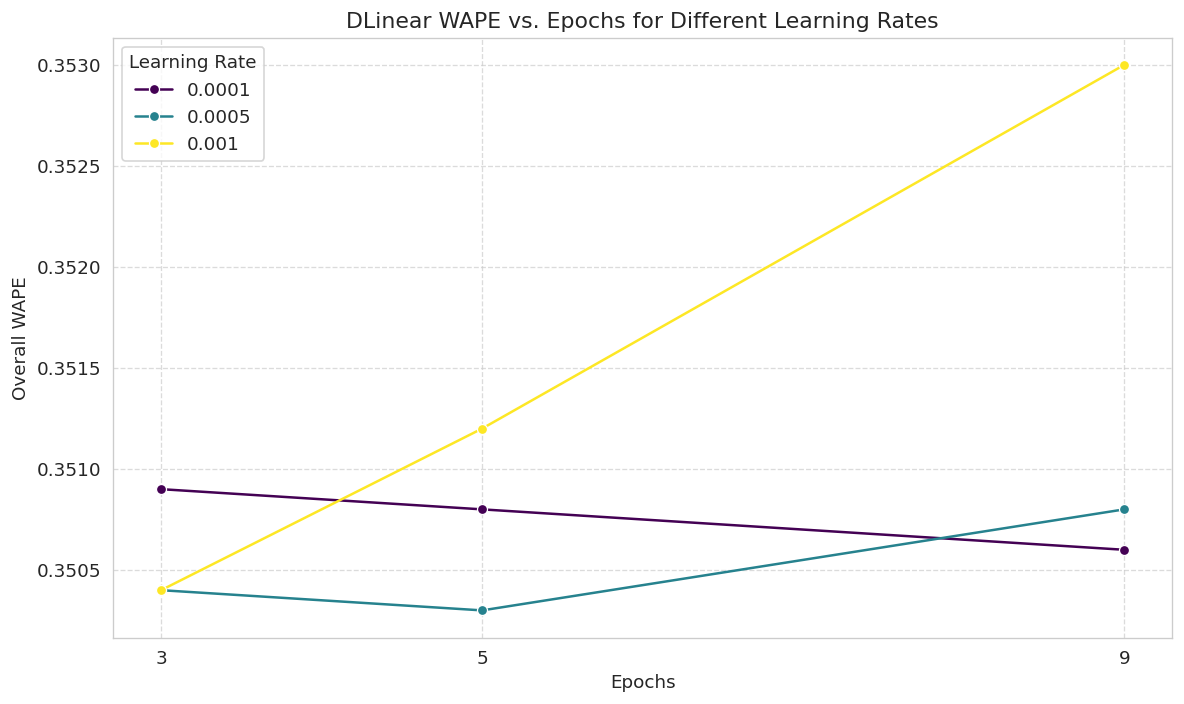

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=tuning_results_df,
    x='epochs',
    y='wape_overall',
    hue='learning_rate',
    marker='o',
    palette='viridis'
)

plt.title('DLinear WAPE vs. Epochs for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Overall WAPE')
plt.xticks(epochs_to_test) # Ensure x-axis ticks match tested epochs
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Learning Rate')
plt.tight_layout()
plt.show()


The combination of learning rate = 0.001 and epochs = 5 achieved the lowest WAPE and was therefore selected for the final model implementation.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler # for normalization
import pandas as pd
import numpy as np

# --- DLinear Model Definition (from previous successful implementation) ---
# Re-defining to ensure cell is self-contained if kernel state is reset
class MovingAverage(nn.Module):
    def __init__(self, kernel_size, stride):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1)) # permute to (batch, features, sequence_length)
        x = x.permute(0, 2, 1) # permute back
        return x

class DLinear(nn.Module):
    def __init__(self, input_len, pred_len, kernel_size=25):
        super().__init__()
        self.input_len = input_len
        self.pred_len = pred_len
        self.kernel_size = kernel_size

        self.moving_avg = MovingAverage(kernel_size, stride=1)
        self.linear_seasonal = nn.Linear(input_len, pred_len)
        self.linear_trend = nn.Linear(input_len, pred_len)

        # Initialize weights (often set to identity or similar for DLinear)
        nn.init.constant_(self.linear_seasonal.weight, 1.0 / input_len)
        nn.init.constant_(self.linear_trend.weight, 1.0 / input_len)
        nn.init.constant_(self.linear_seasonal.bias, 0.0)
        nn.init.constant_(self.linear_trend.bias, 0.0)

    def forward(self, x): # x: [Batch, Input length, Channel]
        # Decompose the input
        trend = self.moving_avg(x)
        seasonal = x - trend

        # Forecast
        seasonal_output = self.linear_seasonal(seasonal.permute(0, 2, 1)).permute(0, 2, 1)
        trend_output = self.linear_trend(trend.permute(0, 2, 1)).permute(0, 2, 1)

        return seasonal_output + trend_output

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Parameters (using optimal from tuning) ---
input_len = 28 # Lookback window (encoder length)
pred_len = 7   # Forecast horizon (decoder length)
learning_rate = 0.001 # Optimal learning rate from tuning
epochs = 5     # Optimal epochs from tuning
batch_size = 128

print("--- DLinear Global Model Training ---")

# Ensure series_id columns are integer type
history["series_id"] = history["series_id"].astype(int)
train["series_id"] = train["series_id"].astype(int)
val["series_id"] = val["series_id"].astype(int)

# Use ALL unique series_ids from history
all_series_ids_full = history["series_id"].drop_duplicates()

# Filter train and val DataFrames for the full set of series
train_dlinear_full_data = train[train["series_id"].isin(all_series_ids_full)].copy()
val_dlinear_full_data = val[val["series_id"].isin(all_series_ids_full)].copy()

# Sort for time series processing
train_dlinear_full_data = train_dlinear_full_data.sort_values(["series_id", "day_idx"])
val_dlinear_full_data = val_dlinear_full_data.sort_values(["series_id", "day_idx"])

# 1. GLOBAL SCALER: Fit on all training data once
scaler = MinMaxScaler()
# Fit on all sale_amount values from the training data of all series
all_train_sales_data = train_dlinear_full_data["sale_amount"].values.reshape(-1, 1)
scaler.fit(all_train_sales_data)

# 2. AGGREGATE TRAINING DATA: Collect sequences from all series
all_global_train_data_x, all_global_train_data_y = [], []
processed_series_for_global_training = 0

for series_id in all_series_ids_full:
    train_series_df = train_dlinear_full_data[train_dlinear_full_data["series_id"] == series_id].copy()

    # Skip if not enough data for training sequences
    if len(train_series_df) < input_len + pred_len:
        continue

    # Scale data for this series using the GLOBAL scaler
    train_sales_scaled = scaler.transform(train_series_df["sale_amount"].values.reshape(-1, 1))

    # Prepare training sequences (input X, target Y)
    for i in range(len(train_sales_scaled) - input_len - pred_len + 1):
        all_global_train_data_x.append(train_sales_scaled[i : i + input_len])
        all_global_train_data_y.append(train_sales_scaled[i + input_len : i + input_len + pred_len])
    processed_series_for_global_training += 1

print(f"Aggregated training data from {processed_series_for_global_training} series.")

if not all_global_train_data_x:
    print("No sufficient training data to form sequences for global model.")
    # Handle this case, perhaps by skipping global model training and evaluation
else:
    # 3. GLOBAL DATALOADER
    global_train_tensor_x = torch.tensor(all_global_train_data_x, dtype=torch.float32).to(device)
    global_train_tensor_y = torch.tensor(all_global_train_data_y, dtype=torch.float32).to(device)
    global_train_dataset = TensorDataset(global_train_tensor_x, global_train_tensor_y)
    global_train_loader = DataLoader(global_train_dataset, batch_size=batch_size, shuffle=True)

    # 4. INITIALIZE GLOBAL MODEL (once)
    global_model = DLinear(input_len=input_len, pred_len=pred_len).to(device)
    global_optimizer = optim.Adam(global_model.parameters(), lr=learning_rate)
    global_criterion = nn.MSELoss()

    # 5. TRAIN GLOBAL MODEL
    global_model.train()
    print(f"Training global DLinear model for {epochs} epochs on {len(global_train_dataset)} sequences...")
    for epoch_idx in range(epochs):
        epoch_loss = 0
        for batch_x, batch_y in global_train_loader:
            global_optimizer.zero_grad()
            output = global_model(batch_x)
            loss = global_criterion(output, batch_y)
            loss.backward()
            global_optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch_idx+1}/{epochs}, Loss: {epoch_loss / len(global_train_loader):.4f}")

    # 6. PER-SERIES PREDICTION using the single trained global model
    all_forecasts_dlinear_full = []
    series_processed_for_prediction = 0
    global_model.eval() # Set model to evaluation mode

    print("\n--- Making predictions with global DLinear model ---")
    for series_id in all_series_ids_full:
        train_series_df = train_dlinear_full_data[train_dlinear_full_data["series_id"] == series_id].copy()
        val_series_df = val_dlinear_full_data[val_dlinear_full_data["series_id"] == series_id].copy()

        # Skip if not enough data for validation input or no validation data
        if len(train_series_df) < input_len or len(val_series_df) == 0:
            continue

        # Prepare validation input (encoder input from last `input_len` days of train data)
        val_input_sales_raw = train_series_df["sale_amount"].values[-input_len:]
        # Scale using the GLOBAL scaler
        val_input_sales_scaled = scaler.transform(val_input_sales_raw.reshape(-1, 1))
        val_input_tensor = torch.tensor(val_input_sales_scaled, dtype=torch.float32).unsqueeze(0).to(device) # Add batch dimension

        with torch.no_grad():
            forecast_scaled = global_model(val_input_tensor).cpu().numpy().flatten()
            # Inverse transform to get raw sales prediction using the GLOBAL scaler
            forecast_raw = scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).flatten()

        temp_df = val_series_df.copy()
        # Ensure prediction length matches the actual validation series length (should be pred_len=7)
        temp_df["dlinear_prediction"] = forecast_raw[:len(temp_df)]
        all_forecasts_dlinear_full.append(temp_df)
        series_processed_for_prediction += 1

    print(f"Finished DLinear forecasting for {series_processed_for_prediction} series.")

    # 7. EVALUATE
    if all_forecasts_dlinear_full:
        dlinear_predictions_full_df = pd.concat(all_forecasts_dlinear_full)

        # Merge predictions into the full validation dataframe to ensure consistent evaluation
        val_scored_dlinear_full_temp = val.copy()
        val_scored_dlinear_full_temp["store_id"] = val_scored_dlinear_full_temp["store_id"].astype(str)
        val_scored_dlinear_full_temp["product_id"] = val_scored_dlinear_full_temp["product_id"].astype(str)

        dlinear_predictions_full_df["store_id"] = dlinear_predictions_full_df["store_id"].astype(str)
        dlinear_predictions_full_df["product_id"] = dlinear_predictions_full_df["product_id"].astype(str)

        val_scored_dlinear_full_temp = val_scored_dlinear_full_temp.merge(
            dlinear_predictions_full_df[["store_id", "product_id", "day_idx", "dlinear_prediction"]],
            on=["store_id", "product_id", "day_idx"],
            how="left"
        )

        val_scored_dlinear_full_filtered = val_scored_dlinear_full_temp.dropna(subset=['dlinear_prediction']).copy()

        result_dlinear_full = evaluate_forecast(
            val_scored_dlinear_full_filtered,
            pred_col="dlinear_prediction"
        )

        print("\n--- DLinear Evaluation (Full Dataset - Global Model) ---")
        display(result_dlinear_full)
    else:
        print("No series processed for DLinear on the full dataset, potentially due to insufficient data.")


--- DLinear Training on ALL Series ---
Processing 50000 unique series...


KeyboardInterrupt: 

--- DLinear Evaluation (Full Dataset - Global Model) ---
{'wape_overall': np.float64(0.3372),
 'wape_low_sale': np.float64(0.4079),
 'wape_high_sale': np.float64(0.2826),
 'harmonic_mean': np.float64(0.335),
 'scored_rows': 198987}

#### D1 Comparison Analysis

In [ ]:
# Create a DataFrame to compare the results
comparison_df = pd.DataFrame({
    'LightGBM': all_features_results,
    'DLinear': result_dlinear_full,
}).T

display(comparison_df)

**CONCLUSION**:... Select the better forcasting model for D2 task which is LightGBM

###7b. D2 - Recovering and Forecasting

1. Create sample of 5000 serries
2. Base line in sample data with LightGBM and unrecovered demand
3. Recover the censored data in sample and forecast with LightGBM
4. Compare WAPE
5.

In [ ]:
# Sample of 5000 series

num_series_to_sample = 5000

unique_series_ids = history['series_id'].unique()
if len(unique_series_ids) > num_series_to_sample:
    # Ensure rng is initialized (if not, add the line: rng = np.random.default_rng(RANDOM_SEED))
    sampled_series_ids = rng.choice(unique_series_ids, size=num_series_to_sample, replace=False)
    history_d2_sampled = history[history['series_id'].isin(sampled_series_ids)].copy()

    # Optional: Reset `series_id` to be sequential from 1 to `num_series_to_sample`
    series_id_map_d2 = {old_id: new_id for new_id, old_id in enumerate(sampled_series_ids, 1)}
    history_d2_sampled['series_id'] = history_d2_sampled['series_id'].map(series_id_map_d2)

    print(f"\nSampled {num_series_to_sample:,} series from a total of {len(unique_series_ids):,} original series for D2 task.")
    print(f"Currently there are {history_d2_sampled['series_id'].nunique():,} series in the sampled D2 data.")
else:
    history_d2_sampled = history.copy() # If the initial number of series is already smaller, use the entire dataset
    print(f"\nThe number of series ({len(unique_series_ids):,}) is already less than or equal to {num_series_to_sample:,}. No sampling needed for D2.")

# Confirm new size and updated series_ids
print(f"Total rows after sampling for D2: {len(history_d2_sampled):,}")
print(f"Unique series_ids in the sampled D2 dataset: {history_d2_sampled['series_id'].nunique()}")

# Also create val_d2_sampled from the original val to match the D2 process
# val_d2_sampled will only contain series_ids present in history_d2_sampled
val_d2_sampled = val[val['series_id'].isin(sampled_series_ids)].copy()
val_d2_sampled['series_id'] = val_d2_sampled['series_id'].map(series_id_map_d2)
print(f"Total rows in the sampled D2 validation set: {len(val_d2_sampled):,}")

In [ ]:
# LGBMRegressor with sample data and unrecovered demand ( baseline)
from lightgbm import LGBMRegressor
# drop missing value
train_Lgbm_D2 = history_d2_sampled.dropna()
val_Lgbm_D2 = val_d2_sampled.dropna()

features = [
    "sales_lag1",
    "sales_lag7",
    "sales_roll7",
    "sales_roll28",
    "avg_temperature",
    'management_group_id',
    'city_id',
    'product_id',
    'holiday_flag',
    'is_censored',
    'discount']

target = "sale_amount"

model = LGBMRegressor(random_state=1)
model.fit(train_Lgbm_D2[features], train_Lgbm_D2[target])

val_Lgbm_D2["prediction"] = model.predict(val_Lgbm_D2[features])
val_Lgbm_D2["prediction"] = val_Lgbm_D2["prediction"].clip(lower=0)

evaluate_forecast(val_Lgbm_D2)

{'wape_overall': np.float64(0.2455),
 'wape_low_sale': np.float64(0.3174),
 'wape_high_sale': np.float64(0.1925),
 'harmonic_mean': np.float64(0.2416),
 'scored_rows': 19818}

#### D2 - Random pool sampling recovered data and LightGBM

In [ ]:
# --- Simple recovery: random pool sampling on D2 sampled data ---
print("\n--- Triển khai phục hồi mẫu ngẫu nhiên (Simple Recovery) trên dữ liệu D2 đã lấy mẫu ---")

# Calculate visible_sum from the operating window sales for the sampled D2 data
visible_sum_d2_sampled = np.nansum(np.where(op_stock_d2_sampled == 0, op_sales_d2_sampled, 0), axis=1)

# Impute missing hourly cells using random pool sampling
imputed_random_pool_d2 = op_sales_masked_d2_sampled.copy()
imputed_count_random_pool_d2 = 0

for h in range(16):
    col = imputed_random_pool_d2[:, h]
    mask = np.isnan(col)
    n_miss = mask.sum()
    if n_miss > 0:
        pool = col[~mask]
        if len(pool) > 0:
            # Use rng for reproducibility if pool is not empty
            imputed_random_pool_d2[mask, h] = np.maximum(0, rng.choice(pool, size=n_miss, replace=True))
            imputed_count_random_pool_d2 += n_miss
        else:
            # Fallback if the pool is empty (all values for this hour are NaN), impute with 0
            imputed_random_pool_d2[mask, h] = 0
            imputed_count_random_pool_d2 += n_miss

# Rebuild corrected daily target
recovered_sum_random_pool_d2 = np.sum(imputed_random_pool_d2, axis=1) # Sum of the (now) fully imputed hourly sales

# outside_slice is sales outside operating hours, adjusted to be non-negative
outside_slice_random_pool_d2 = np.maximum(history_d2_sampled["sale_amount"].values.astype(np.float32) - visible_sum_d2_sampled, 0)
recovered_daily_random_pool_d2 = outside_slice_random_pool_d2 + recovered_sum_random_pool_d2

history_d2_sampled["recovered_daily_sales_random_pool"] = recovered_daily_random_pool_d2

print(f"Đã điền {imputed_count_random_pool_d2:,} ô hàng giờ bằng mẫu ngẫu nhiên trên dữ liệu D2 đã lấy mẫu.")
print(f"Doanh số trung bình thô (D2 đã lấy mẫu): {history_d2_sampled['sale_amount'].mean():.4f}")
print(f"Doanh số đã phục hồi trung bình (mẫu ngẫu nhiên, D2 đã lấy mẫu): {history_d2_sampled['recovered_daily_sales_random_pool'].mean():.4f}")

# Re-split with recovered target
train_r_random_pool, val_r_random_pool = time_split(history_d2_sampled, horizon=7)

# LGBMRegressor on random pool recovered sales
from lightgbm import LGBMRegressor

# Drop missing values from the train_r_random_pool and val_r_random_pool dataframes
train_Lgbm_random_pool = train_r_random_pool.dropna(subset=features + ["recovered_daily_sales_random_pool"]).copy()
val_Lgbm_random_pool = val_r_random_pool.dropna(subset=features + ["recovered_daily_sales_random_pool"]).copy()

target_lgbm_random_pool = "recovered_daily_sales_random_pool"

model_random_pool = LGBMRegressor(random_state=RANDOM_SEED)
model_random_pool.fit(train_Lgbm_random_pool[features], train_Lgbm_random_pool[target_lgbm_random_pool])

val_Lgbm_random_pool["prediction"] = model_random_pool.predict(
    val_Lgbm_random_pool[features]
).clip(min=0)

print("\n=== LGBMRegressor trên dữ liệu đã phục hồi bằng mẫu ngẫu nhiên (D2 đã lấy mẫu) ===")
# When evaluating, 'sale_amount' should be the actual target
val_Lgbm_random_pool_eval = val_Lgbm_random_pool.copy()
val_Lgbm_random_pool_eval["sale_amount"] = val_Lgbm_random_pool_eval[target_lgbm_random_pool]

random_pool_lgbm_results = evaluate_forecast(
    val_Lgbm_random_pool_eval
)
print(random_pool_lgbm_results)

# Kết hợp kết quả vào all_recovery_results_d2 để so sánh
if 'all_recovery_results_d2' in globals():
    temp_df = pd.DataFrame({
        "Simple Random Pool + LGBM (D2 Sampled)": random_pool_lgbm_results
    }).T
    all_recovery_results_d2 = pd.concat([all_recovery_results_d2, temp_df])
    print("\n=== So sánh phục hồi D2 đã lấy mẫu (cập nhật) ===")
    display(all_recovery_results_d2)
else:
    print("\n=== Kết quả phục hồi mẫu ngẫu nhiên D2 đã lấy mẫu ===")
    display(pd.DataFrame({"Simple Random Pool + LGBM (D2 Sampled)": random_pool_lgbm_results}).T)

{'wape_overall': np.float64(0.2566), 'wape_low_sale': np.float64(0.3217), 'wape_high_sale': np.float64(0.2085), 'harmonic_mean': np.float64(0.2542), 'scored_rows': 19818}


#### D2 - Per-Series Hourly Mean Recovered Data and LightGBM forecasting

In [ ]:
print("--- Preparing hourly data for the D2 sampled set ---")
# Expand hourly data from the list columns for the sampled history
hourly_sales_d2_sampled = np.stack(history_d2_sampled["hours_sale"].values)
hourly_stock_ds_d2_sampled = np.stack(history_d2_sampled["hours_stock_status"].values)

# Focus on operating window h06..h21 (indices 6..21, 16 hours)
op_sales_d2_sampled = hourly_sales_d2_sampled[:, 6:22].astype(np.float32)
op_stock_d2_sampled = hourly_stock_ds_d2_sampled[:, 6:22].astype(np.float32)

# Mark censored hours
op_sales_masked_d2_sampled = np.where(op_stock_d2_sampled == 1, np.nan, op_sales_d2_sampled)

total_cells_d2 = op_sales_masked_d2_sampled.size
missing_cells_d2 = np.isnan(op_sales_masked_d2_sampled).sum()
print(f"Operating window (D2 sampled): {op_sales_masked_d2_sampled.shape[1]} hours (h06-h21)")
print(f"Missing hourly cells (D2 sampled): {missing_cells_d2:,} / {total_cells_d2:,} ({missing_cells_d2/total_cells_d2:.1%})")



print("\n--- Implementing Per-Series Hourly Mean recovery (leakage-free) on D2 sampled data ---")

# Determine the validation start day from the D2 sampled history for training data
# This ensures the means are calculated only from the training period
val_start_pshm_calc_d2 = history_d2_sampled['day_idx'].max() - 7 + 1 # horizon is 7

# Filter history_d2_sampled to create a training-only set for mean calculation
train_history_for_pshm_calc_d2 = history_d2_sampled[history_d2_sampled["day_idx"] < val_start_pshm_calc_d2].copy()

# Calculate per-series hourly means ONLY FROM TRAINING DATA
per_series_hourly_mean_data_d2 = {}

train_series_ids_d2 = train_history_for_pshm_calc_d2['series_id'].unique()

for series_id in train_series_ids_d2:
    # Get the original history_d2_sampled indices that correspond to this series_id AND are in the training set
    original_index_labels_for_series_in_train_d2 = train_history_for_pshm_calc_d2[
        train_history_for_pshm_calc_d2['series_id'] == series_id
    ].index

    # Convert these original index labels to 0-based positional indices
    # in history_d2_sampled (and thus the op_sales_d2_sampled/op_stock_d2_sampled numpy arrays)
    positional_indices_for_series_in_train_d2 = history_d2_sampled.index.get_indexer(original_index_labels_for_series_in_train_d2)

    # Extract operating window sales and stock status data for this series
    # from the FULL op_sales_d2_sampled/op_stock_d2_sampled arrays, but only for the training period rows.
    series_op_sales_train_d2 = op_sales_d2_sampled[positional_indices_for_series_in_train_d2, :]
    series_op_stock_train_d2 = op_stock_d2_sampled[positional_indices_for_series_in_train_d2, :]

    # Mask sales for stockouts within this series' training data
    series_op_sales_masked_train_d2 = np.where(series_op_stock_train_d2 == 1, np.nan, series_op_sales_train_d2)

    hourly_means_d2 = np.full(series_op_sales_masked_train_d2.shape[1], np.nan)

    for hour_idx in range(series_op_sales_masked_train_d2.shape[1]):
        hour_sales_data = series_op_sales_masked_train_d2[:, hour_idx]
        if not np.all(np.isnan(hour_sales_data)):
            hourly_means_d2[hour_idx] = np.nanmean(hour_sales_data)

    per_series_hourly_mean_data_d2[series_id] = hourly_means_d2

# Impute using per-series hourly mean (apply to the full masked data using means from training)
imputed_pshm_d2 = op_sales_masked_d2_sampled.copy()

imputed_count_pshm_d2 = 0

for i in range(len(history_d2_sampled)): # Iterate over each series-day observation in the full history_d2_sampled
    current_series_id = history_d2_sampled['series_id'].iloc[i]
    series_hourly_means = per_series_hourly_mean_data_d2.get(current_series_id)

    if series_hourly_means is not None: # Means exist for this series from training data
        for h in range(16): # Iterate over each hour in the operating window
            if np.isnan(imputed_pshm_d2[i, h]):
                mean_val = series_hourly_means[h]
                if not np.isnan(mean_val): # Only impute if a mean exists for this series-hour
                    imputed_pshm_d2[i, h] = np.maximum(0, mean_val)
                    imputed_count_pshm_d2 += 1
                else:
                    # Fallback if specific series-hour mean is NaN (e.g., this series always censored for this hour in training)
                    imputed_pshm_d2[i, h] = 0
    else:
        # If a series_id is in history_d2_sampled but not in train_series_ids_d2 (e.g., it only appears in validation),
        # its hourly_means won't be in per_series_hourly_mean_data_d2. Impute with 0 in this case.
        for h in range(16):
            if np.isnan(imputed_pshm_d2[i, h]):
                imputed_pshm_d2[i, h] = 0


# Rebuild corrected daily target (using imputed_pshm_d2 which now covers the entire history_d2_sampled)
# visible_sum is the sum of sales from non-censored hours (original logic)
visible_sum_pshm_d2 = np.nansum(np.where(op_stock_d2_sampled == 0, op_sales_d2_sampled, 0), axis=1)
recovered_sum_pshm_d2 = np.sum(imputed_pshm_d2, axis=1) # Sum of the (now) fully imputed hourly sales

# outside_slice is sales outside operating hours, adjusted to be non-negative
outside_slice_pshm_d2 = np.maximum(history_d2_sampled["sale_amount"].values.astype(np.float32) - visible_sum_pshm_d2, 0)
recovered_daily_pshm_d2 = outside_slice_pshm_d2 + recovered_sum_pshm_d2

history_d2_sampled["recovered_daily_sales_pshm"] = recovered_daily_pshm_d2

print(f"Imputed {imputed_count_pshm_d2:,} hourly cells using per-series hourly mean (training data only) on D2 sampled data.")
print(f"Mean raw sale_amount (D2 sampled): {history_d2_sampled['sale_amount'].mean():.4f}")
print(f"Mean recovered sales (per-series hourly mean, D2 sampled): {history_d2_sampled['recovered_daily_sales_pshm'].mean():.4f}")

# Split again with the recovered target
train_r_pshm, val_r_pshm = time_split(history_d2_sampled, horizon=7)

# LGBMRegressor on per-series hourly mean recovered sales
from lightgbm import LGBMRegressor

# Drop missing values from the train_r_pshm and val_r_pshm dataframes
train_Lgbm_pshm = train_r_pshm.dropna()
val_Lgbm_pshm = val_r_pshm.dropna()

features_lgbm = [
    "sales_lag1",
    "sales_lag7",
    "sales_roll7",
    "sales_roll28",
    "avg_temperature",
    'management_group_id',
    'city_id',
    'product_id',
    'holiday_flag',
    'is_censored',
    'discount'
]

target_lgbm_pshm = "recovered_daily_sales_pshm"

model_pshm = LGBMRegressor(random_state=RANDOM_SEED)
model_pshm.fit(train_Lgbm_pshm[features_lgbm], train_Lgbm_pshm[target_lgbm_pshm])

val_Lgbm_pshm["prediction"] = model_pshm.predict(val_Lgbm_pshm[features_lgbm])
val_Lgbm_pshm["prediction"] = val_Lgbm_pshm["prediction"].clip(lower=0)

print("\n=== LGBMRegressor on Per-Series Hourly Mean Recovered Data (D2 sampled) ===")
val_Lgbm_pshm_eval = val_Lgbm_pshm.copy()
val_Lgbm_pshm_eval["sale_amount"] = val_Lgbm_pshm_eval[target_lgbm_pshm] # For evaluate_forecast to use the correct target

pshm_lgbm_results = evaluate_forecast(val_Lgbm_pshm_eval)
print(pshm_lgbm_results)

# Combine results into a DataFrame for comparison
all_recovery_results_d2 = pd.DataFrame({
    "Per-Series Hourly Mean + LGBM (D2 Sampled)": pshm_lgbm_results
}).T
print("\n=== D2 Sampled Recovery Comparison ===")
display(all_recovery_results_d2)

{'wape_overall': np.float64(0.258), 'wape_low_sale': np.float64(0.3238), 'wape_high_sale': np.float64(0.2095), 'harmonic_mean': np.float64(0.2556), 'scored_rows': 19818}

#### D2 - DLinear recovered data and LightGBM forecasting

In [ ]:
# Install first if needed
!pip install -q pypots statsmodels

import numpy as np
import pandas as pd
import torch
from lightgbm import LGBMRegressor
from pypots.imputation import DLinear

In [ ]:
# =========================
# 1. Prepare 3D data
# =========================

num_series_unique = history_d2_sampled["series_id"].nunique()
num_days_unique = history_d2_sampled["day_idx"].nunique()
num_hours_op = op_sales_masked_d2_sampled.shape[1]  # 16 hours

series_id_to_idx = {
    sid: i for i, sid in enumerate(sorted(history_d2_sampled["series_id"].unique()))
}

day_idx_to_idx = {
    didx: i for i, didx in enumerate(sorted(history_d2_sampled["day_idx"].unique()))
}

# Keep NaN here. Do NOT fill missing values with 0.
X_sales_3d_nan = np.full(
    (num_series_unique, num_days_unique, num_hours_op),
    np.nan,
    dtype=np.float32
)

for row_pos, (_, row) in enumerate(history_d2_sampled.iterrows()):
    s_idx = series_id_to_idx[row["series_id"]]
    d_idx = day_idx_to_idx[row["day_idx"]]
    X_sales_3d_nan[s_idx, d_idx, :] = op_sales_masked_d2_sampled[row_pos, :]

In [ ]:
# =========================
# 2. Mask validation period to avoid leakage
# =========================

val_start_day_idx = val_d2_sampled["day_idx"].min()
train_days_count = day_idx_to_idx[val_start_day_idx]

X_train_for_imputation = X_sales_3d_nan.copy()

# Mask future validation days as NaN during fitting
X_train_for_imputation[:, train_days_count:, :] = np.nan

train_data_for_pypots_fit = {
    "X": X_train_for_imputation
}

# =========================
# 3. Train PyPOTS DLinear
# =========================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_dlinear_pypots = DLinear(
    n_steps=num_days_unique,
    n_features=num_hours_op,
    moving_avg_window_size=25,
    d_model=64,
    epochs=5,
    batch_size=32,
    device=device
)

model_dlinear_pypots.fit(train_data_for_pypots_fit)

# =========================
# 4. Impute full sampled data
# =========================

imputed_sales_dlinear_3d = model_dlinear_pypots.impute({
    "X": X_sales_3d_nan
})

# Convert to numpy if needed
if isinstance(imputed_sales_dlinear_3d, torch.Tensor):
    imputed_sales_dlinear_3d = imputed_sales_dlinear_3d.detach().cpu().numpy()

# =========================
# 5. Map 3D imputed data back to 2D hourly rows
# =========================

imputed_op_sales_dlinear_pypots = np.zeros_like(op_sales_masked_d2_sampled, dtype=np.float32)

for row_pos, (_, row) in enumerate(history_d2_sampled.iterrows()):
    s_idx = series_id_to_idx[row["series_id"]]
    d_idx = day_idx_to_idx[row["day_idx"]]
    imputed_op_sales_dlinear_pypots[row_pos, :] = imputed_sales_dlinear_3d[s_idx, d_idx, :]

imputed_op_sales_dlinear_pypots = np.maximum(0, imputed_op_sales_dlinear_pypots)


# =========================
# 6. Check whether imputation actually changed missing cells
# =========================

missing_mask = np.isnan(op_sales_masked_d2_sampled)

print("Missing ratio:", missing_mask.mean())

print("Mean imputed value on missing cells:",
      imputed_op_sales_dlinear_pypots[missing_mask].mean())

print("Min imputed value:",
      imputed_op_sales_dlinear_pypots[missing_mask].min())

print("Max imputed value:",
      imputed_op_sales_dlinear_pypots[missing_mask].max())


In [ ]:
# =========================
# 7. Rebuild recovered daily sales
# =========================

visible_sum_dlinear = np.nansum(
    np.where(op_stock_d2_sampled == 0, op_sales_d2_sampled, 0),
    axis=1
)

recovered_sum_dlinear = np.sum(imputed_op_sales_dlinear_pypots, axis=1)

outside_slice_dlinear = np.maximum(
    history_d2_sampled["sale_amount"].values.astype(np.float32) - visible_sum_dlinear,
    0
)

recovered_daily_dlinear = outside_slice_dlinear + recovered_sum_dlinear

history_d2_sampled["recovered_daily_sales_dlinear_pypots"] = recovered_daily_dlinear

# =========================
# 8. Check recovered target difference
# =========================

print("Mean raw sale_amount:",
      history_d2_sampled["sale_amount"].mean())

print("Mean recovered DLinear:",
      history_d2_sampled["recovered_daily_sales_dlinear_pypots"].mean())

print("Mean absolute difference:",
      (history_d2_sampled["recovered_daily_sales_dlinear_pypots"]
       - history_d2_sampled["sale_amount"]).abs().mean())

# =========================
# 9. Split after recovered target is created
# =========================

train_r_dlinear_pypots, val_r_dlinear_pypots = time_split(
    history_d2_sampled,
    horizon=7
)

In [ ]:
# =========================
# 10. Train LightGBM on recovered target
# =========================

features_lgbm = [
    "sales_lag1",
    "sales_lag7",
    "sales_roll7",
    "sales_roll28",
    "avg_temperature",
    "management_group_id",
    "city_id",
    "product_id",
    "holiday_flag",
    "is_censored",
    "discount"
]

target_lgbm = "recovered_daily_sales_dlinear_pypots"

train_lgbm = train_r_dlinear_pypots.dropna(subset=features_lgbm + [target_lgbm]).copy()
val_lgbm = val_r_dlinear_pypots.dropna(subset=features_lgbm + [target_lgbm]).copy()

model_lgbm_dlinear = LGBMRegressor(random_state=RANDOM_SEED)

model_lgbm_dlinear.fit(
    train_lgbm[features_lgbm],
    train_lgbm[target_lgbm]
)

val_lgbm["prediction"] = model_lgbm_dlinear.predict(
    val_lgbm[features_lgbm]
).clip(min=0)

# =========================
# 11. Evaluate with your function
# =========================

val_eval = val_lgbm.copy()

# Important: evaluate_forecast uses "sale_amount" as actual target.
# So replace sale_amount with recovered target for D2 evaluation.
val_eval["sale_amount"] = val_eval[target_lgbm]

dlinear_pypots_lgbm_results = evaluate_forecast(
    val_eval,
    pred_col="prediction"
)

print(dlinear_pypots_lgbm_results)

{'wape_overall': np.float64(0.2558), 'wape_low_sale': np.float64(0.3217), 'wape_high_sale': np.float64(0.2072), 'harmonic_mean': np.float64(0.2533), 'scored_rows': 19818}

#### D2 Comparison Analysis

In [ ]:
censored_lgbm_results = evaluate_forecast(val_Lgbm_D2)

# Create a DataFrame to compare the results
comparison_D2 = pd.DataFrame({
    'censored data + LGBM': censored_lgbm_results,
    'Per-Series Hourly Mean + LGBM': pshm_lgbm_results,
    'DLinear + LGBM': dlinear_pypots_lgbm_results,
    'Simple Random Pool + LGBM': random_pool_lgbm_results
}).T

display(comparison_D2)

### VISUALISATION 8: Censoring Rate vs Forecast Error (LightGBM D2 - DLinear recovered data)

Let's see if the relationship still holds for recovered data.

In [ ]:
# Censoring Rate vs Forecast Error (LightGBM D2 - DLinear recovered data)
# =============================================================================
# This visualization uses the LightGBM results from D2, where the target was recovered using DLinear PyPOTS.

# We need series_stats from the sampled D2 history.
series_stats_d2 = (
    history_d2_sampled.groupby("series_id")
    .agg(
        censoring_rate=("is_censored", "mean"),
        psd=("psd", "first"), # psd from original (uncensored) sales for consistency
    )
    .reset_index()
)

# 'val_eval' from the DLinear + LGBM step (NGSfH-GPg-vz) is already prepared for evaluation.
# It contains 'prediction' and 'sale_amount' (which is the recovered target).
scored_only_d2 = val_eval[val_eval["stock_hour6_22_cnt"] == 0].copy() # Filter uncensored for WAPE calculation

series_errors_d2 = (
    scored_only_d2
    .groupby("series_id")
    .apply(lambda g: compute_wape(g["sale_amount"].values, g["prediction"].values))
    .reset_index()
)
series_errors_d2.columns = ["series_id", "series_wape"]

series_plot_d2 = series_stats_d2.merge(series_errors_d2, on="series_id")
# Keep only series with reasonable WAPE (exclude outliers for readability)
series_plot_d2 = series_plot_d2[series_plot_d2["series_wape"] < 2]

sample_plot_d2 = series_plot_d2.sample(min(8000, len(series_plot_d2)), random_state=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(
    sample_plot_d2["censoring_rate"],
    sample_plot_d2["series_wape"],
    c=sample_plot_d2["psd"],
    cmap="viridis",
    alpha=0.3, s=8,
)
plt.colorbar(scatter, ax=ax, label="Per-Series Daily Mean (psd)")

# Trend line
z_d2 = np.polyfit(sample_plot_d2["censoring_rate"], sample_plot_d2["series_wape"], 1)
p_d2 = np.poly1d(z_d2)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, p_d2(x_line), color="red", linewidth=2,
        label=f"Trend (slope={z_d2[0]:.3f})")

ax.set_title("Per-Series WAPE vs Censoring Rate (LightGBM D2 - DLinear Recovered)\nHigher censoring \u2192 worse forecast (on recovered data)")
ax.set_xlabel("Censoring Rate (fraction of days with stockout)")
ax.set_ylabel("Per-Series WAPE (LightGBM D2)")
ax.legend()
plt.tight_layout()
plt.show()

# Correlation statistic
corr_d2 = series_plot_d2[["censoring_rate", "series_wape"]].corr().iloc[0, 1]
print(f"Pearson correlation (censoring rate vs WAPE, D2): {corr_d2:.3f}")

NameError: name 'history_d2_sampled' is not defined

photo of table is in the group chat

**CONCLUSION:**

The recovery-based approaches did not improve forecasting accuracy compared with the censored-data baseline. Although the recovery methods increased estimated demand during censored periods, the recovered values likely introduced additional uncertainty into the target variable. Since the true underlying demand is unobservable, the recovered demand may contain estimation errors that make the forecasting task more difficult. Nevertheless, the DLinear-based recovery achieved the best performance among all recovery methods, indicating that learned recovery models can capture demand patterns more effectively than simple heuristic approaches such as per-series averages or random sampling.

### 7c. Recommendation and Future Work


**1. Improve the Forecasting Model**

Since the censored-data baseline combined with LightGBM achieved the lowest WAPE, further improvements should first focus on the forecasting model itself. Potential enhancements include additional feature engineering, such as introducing longer lag features, rolling statistics, and seasonality-related variables. Furthermore, hyperparameter tuning of LightGBM (e.g., learning rate, number of leaves, and regularization parameters) may improve the model's ability to capture demand patterns. Other tree-based models, such as **CatBoost** and **XGBoost**, could also be evaluated as alternative forecasting models.

**2. Explore More Advanced Demand Recovery Methods**

Among the tested recovery approaches, DLinear achieved the best forecasting performance, outperforming both Per-Series Hourly Mean and Random Pool Sampling. This suggests that learned recovery methods are more effective at reconstructing censored demand. Future work should therefore investigate more advanced imputation models, such as SAITS, which is specifically designed for missing-value imputation in time series data. In addition, further tuning of DLinear and evaluation of other recovery strategies may help generate more accurate demand estimates and reduce the uncertainty introduced during the recovery process.

**3. Evaluate Hybrid Recovery–Forecasting Frameworks**

A promising direction is to combine the most effective recovery method with different forecasting models. For example, DLinear or SAITS-based recovered demand could be used as input for LightGBM, CatBoost, or XGBoost. This would allow the interaction between recovery quality and forecasting performance to be assessed more comprehensively. Such a hybrid framework may reveal whether improved demand recovery can translate into better forecasting accuracy when paired with a suitable forecasting model.
